# <font color="steelblue">Regresión logística para clasificación múltiple</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 05/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             make_scorer, precision_score, recall_score, f1_score)
RNG = 42

# <font color="steelblue">Introducción</font>

Cuando la respuesta tiene **más de dos clases** ($K>2$), la regresión logística se generaliza de dos formas: **uno-contra-el-resto** (*One-vs-Rest*) y **multinomial** (*softmax*). Mantiene todas sus virtudes —es **lineal**, **probabilística** e **interpretable**— y en scikit-learn se usa con la **misma clase** `LogisticRegression`. Este cuaderno da por conocido el de **clasificación binaria**.

# <font color="steelblue">1. De binaria a multiclase: One-vs-Rest y softmax</font>

Recordemos el caso binario: $P(y=1\mid x)=\sigma(w^\top x+b)$, con una **frontera lineal**. Para $K>2$ clases hay dos enfoques.

## <font color="steelblue">1.1. Uno-contra-el-resto (*One-vs-Rest*, OvR)</font>

Se entrena **un clasificador binario por clase**: el $k$-ésimo aprende a separar "clase $k$" frente a "todas las demás". Para predecir, se aplican los $K$ modelos a la muestra y se elige la clase cuyo modelo da **mayor probabilidad**. Es simple y siempre aplicable, pero las $K$ probabilidades se estiman por separado y **no suman 1** de forma natural (hay que normalizar), y cada modelo ve un problema desbalanceado (1 clase frente a $K-1$).

## <font color="steelblue">1.2. Multinomial (*softmax*)</font>

El enfoque **multinomial** modela las $K$ clases **conjuntamente**. Cada clase $k$ tiene su propio vector de coeficientes $w_k$ (y sesgo $b_k$), produciendo una **puntuación** lineal $z_k = w_k^\top x + b_k$. Esas puntuaciones se convierten en probabilidades con la función **softmax**:

$$P(y=k\mid x)=\frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}.$$

La softmax es la **generalización de la sigmoide**: exponencia cada puntuación (para que sea positiva) y **normaliza** dividiendo por la suma, de modo que las $K$ probabilidades son positivas y **suman 1**. La clase predicha es la de **mayor** $z_k$ (equivalente, mayor probabilidad). Propiedades clave:

* Para $K=2$ la softmax se reduce **exactamente** a la sigmoide.
* Es **invariante** a sumar una constante a todas las puntuaciones (solo importan las **diferencias** $z_k - z_j$): por eso una clase se toma como referencia.
* Da probabilidades **mejor calibradas** que OvR porque las estima de forma acoplada.

Es el método **por defecto** en scikit-learn cuando el `solver` lo admite (`lbfgs`, `newton-cg`, `sag`, `saga`).

## <font color="steelblue">1.3. Fronteras de decisión</font>

Cada par de clases queda separado por un **hiperplano** (donde $z_k=z_j$); el espacio se divide en **regiones poligonales** (lineales a trozos), una por clase. Lo visualizaremos en el ejemplo de juguete.

# <font color="steelblue">2. Interpretación de los coeficientes en multiclase</font>

En multinomial, el modelo ajusta **un vector de coeficientes por clase**: el atributo `coef_` tiene forma **$(K, p)$** (una fila por clase, una columna por variable). La fila $k$ se interpreta como el efecto de las variables sobre la **puntuación** de la clase $k$:

* un coeficiente **positivo** $w_{kj}>0$ indica que, al aumentar la variable $j$, **crece** la puntuación (y la probabilidad relativa) de la clase $k$;
* un coeficiente **negativo** la **reduce**.

Igual que en binaria, $e^{w_{kj}}$ es un **odds ratio**, ahora interpretado como el efecto de la variable $j$ sobre los odds de "ser de la clase $k$ frente a la referencia". Como hay $K$ filas, lo más cómodo es visualizar `coef_` como un **mapa de calor** (clases × variables): de un vistazo se ve **qué variables caracterizan cada clase** (positivas en una fila, negativas en otra). Con las variables **estandarizadas**, las magnitudes son comparables. Lo haremos con los datos reales (sección 8.3).

# <font color="steelblue">3. Estimación: entropía cruzada multiclase</font>

Igual que en binaria, se estima por **máxima verosimilitud**, minimizando la **entropía cruzada** (generalización de la *log-loss*). Codificando la clase real con un vector *one-hot* $y_{ik}$ (vale 1 si la muestra $i$ es de la clase $k$, 0 si no):

$$\mathcal{L}= -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik}\,\log P(y=k\mid x_i).$$

Para cada muestra solo "cuenta" el término de su clase verdadera, $-\log P(\text{clase correcta})$: el coste es 0 si el modelo le asigna probabilidad 1 a la clase correcta y crece sin límite si le asigna probabilidad próxima a 0. La función es **convexa**, así que el `solver` converge al **mínimo global**.

# <font color="steelblue">4. Modelos regularizados e hiperparámetros</font>

Analizamos las opciones de entrenamiento para este modelo.

## <font color="steelblue">4.1. Regularización</font>

Como en binaria, se añade a la entropía cruzada un término de **penalización** $\tfrac{1}{C}R(w)$ sobre el tamaño de los coeficientes, para evitar el **sobreajuste**. El efecto sobre la estimación es el mismo compromiso sesgo–varianza: los coeficientes se **encogen** hacia 0, ganando estabilidad. Las opciones son idénticas: **L2** (encoge sin anular), **L1** (anula coeficientes → selección), **Elastic-Net** (mezcla) y **None**; e **`C`** es el inverso de la fuerza de regularización (pequeño = más regularización).

## <font color="steelblue">4.2. Descripción de los hiperparámetros y cómo optimizarlos</font>

| Hiperparámetro | Qué controla | Cómo proceder en la optimización |
|---|---|---|
| **`C`** | Inverso de la regularización (el más importante) | Barrer en **escala logarítmica**: `[0.001, 0.01, 0.1, 1, 10, 100]`. |
| **`penalty`** | Tipo de penalización (`'l2'`, `'l1'`, `'elasticnet'`, `None`) | `l2` por defecto; `l1` si se busca selección; `elasticnet` con predictoras correlacionadas. |
| **`solver`** | Algoritmo de optimización | Para multinomial: `lbfgs`/`newton-cg`/`sag`/`saga`. `'saga'` admite además `l1`/`elasticnet`. |
| **`l1_ratio`** | Mezcla L1/L2 (solo `elasticnet`) | Barrer `[0, 0.25, 0.5, 0.75, 1]`. |
| **`class_weight`** | Pondera las clases | `'balanced'` si hay **clases minoritarias** (sección 10). |
| **`max_iter`** | Iteraciones del solver | Subirlo (p. ej. `5000`) si avisa de **no convergencia**. |

**Importante (métrica en multiclase).** Al validar u optimizar usaremos *scorers* **promediados entre clases**: `'f1_weighted'` (media de los f1 por clase ponderada por su frecuencia), adecuado cuando las clases están algo desbalanceadas. (`'f1'` a secas solo vale para problemas binarios.)







## <font color="steelblue">4.3. Compatibilidad `penalty` ↔ `solver`</font>

| penalty | solvers compatibles |
|---|---|
| `l2` | lbfgs, newton-cg, sag, saga |
| `l1` | saga (y liblinear en OvR) |
| `elasticnet` | saga |
| `None` | lbfgs, newton-cg, sag, saga |

# <font color="steelblue">5. Qué devuelve el modelo multiclase</font>

Tras entrenar, el modelo ofrece tres salidas (como en binaria, pero con $K$ valores):

1. **Puntuaciones** — `decision_function(X)` devuelve una matriz $n\times K$ con los $z_k=w_k^\top x+b_k$. La clase predicha es la del **mayor** $z_k$.
2. **Probabilidades** — `predict_proba(X)` aplica la **softmax** y devuelve una matriz $n\times K$ donde **cada fila suma 1**. Es la salida más rica: dice no solo la clase, sino **el reparto de probabilidad** entre todas (p. ej. "70 % clase A, 25 % B, 5 % C"), lo que permite detectar predicciones **dudosas** (probabilidades repartidas) y ordenar por confianza.
3. **Clase predicha** — `predict(X)` devuelve directamente la clase de mayor probabilidad (equivale a `argmax` de `predict_proba`).

La **interpretabilidad** se mantiene: `coef_` $(K,p)$ e `intercept_` $(K,)$ describen cada clase, y $e^{w_{kj}}$ son odds ratios por clase. Conviene **estandarizar** las predictoras (lo hace `preprocesar_datos`).

# <font color="steelblue">6. Ejemplo de juguete: regiones de decisión</font>

Tomamos **dos variables** del conjunto *Iris* (para poder dibujar) y sus **tres** especies. Antes de modelar, describimos los datos: **equilibrio de clases** y **distribución de cada variable** por especie.

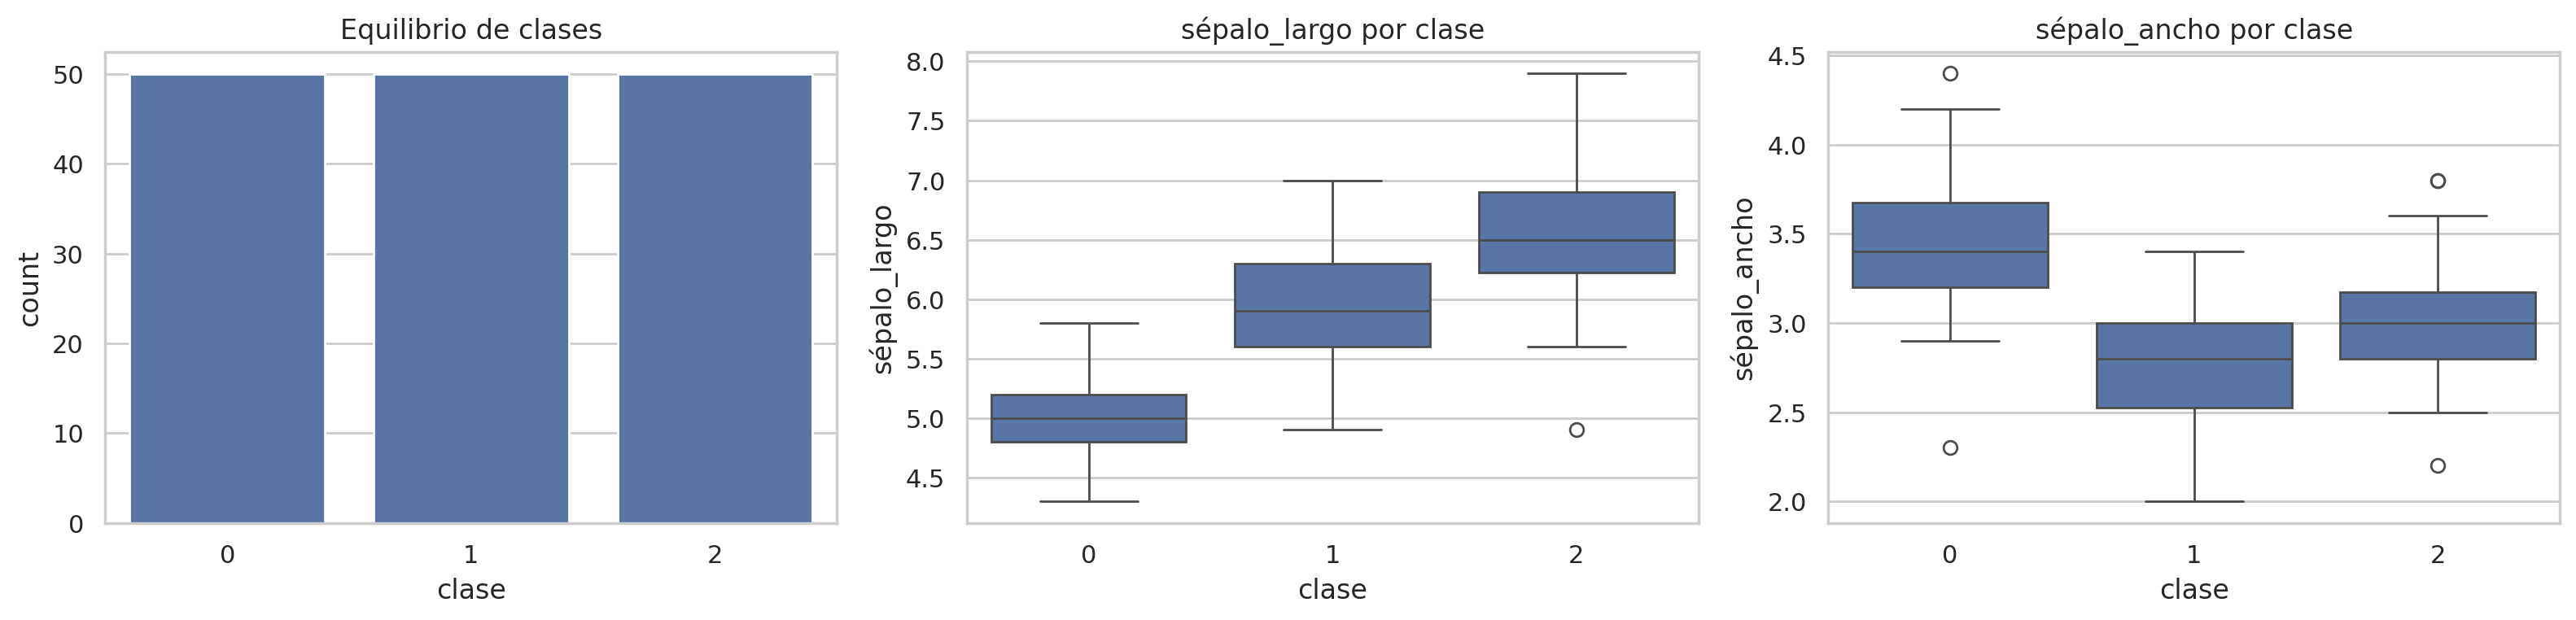

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
Xt = iris.data[:, :2]                 # 2 variables: largo y ancho del sépalo
yt = iris.target                      # 3 clases
toy = pd.DataFrame(Xt, columns=['sépalo_largo', 'sépalo_ancho']); toy['clase'] = yt

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='clase', data=toy, ax=ax[0])
ax[0].set_title('Equilibrio de clases')
sns.boxplot(x='clase', y='sépalo_largo', data=toy, ax=ax[1])
ax[1].set_title('sépalo_largo por clase')
sns.boxplot(x='clase', y='sépalo_ancho', data=toy, ax=ax[2])
ax[2].set_title('sépalo_ancho por clase')
plt.tight_layout(); plt.show()

Las tres clases están **perfectamente equilibradas** (50 cada una). Los diagramas de caja muestran que la clase 0 se separa bien por el largo del sépalo, mientras que las clases 1 y 2 se **solapan** en ambas variables: anticipamos que el modelo separará bien la 0 y cometerá algún error entre 1 y 2. Como en el caso real, **estandarizamos** las dos variables antes de ajustar (la regresión logística regularizada lo requiere para tratar por igual a todas las predictoras); después ajustamos la regresión logística multinomial y dibujamos las **regiones de decisión**.

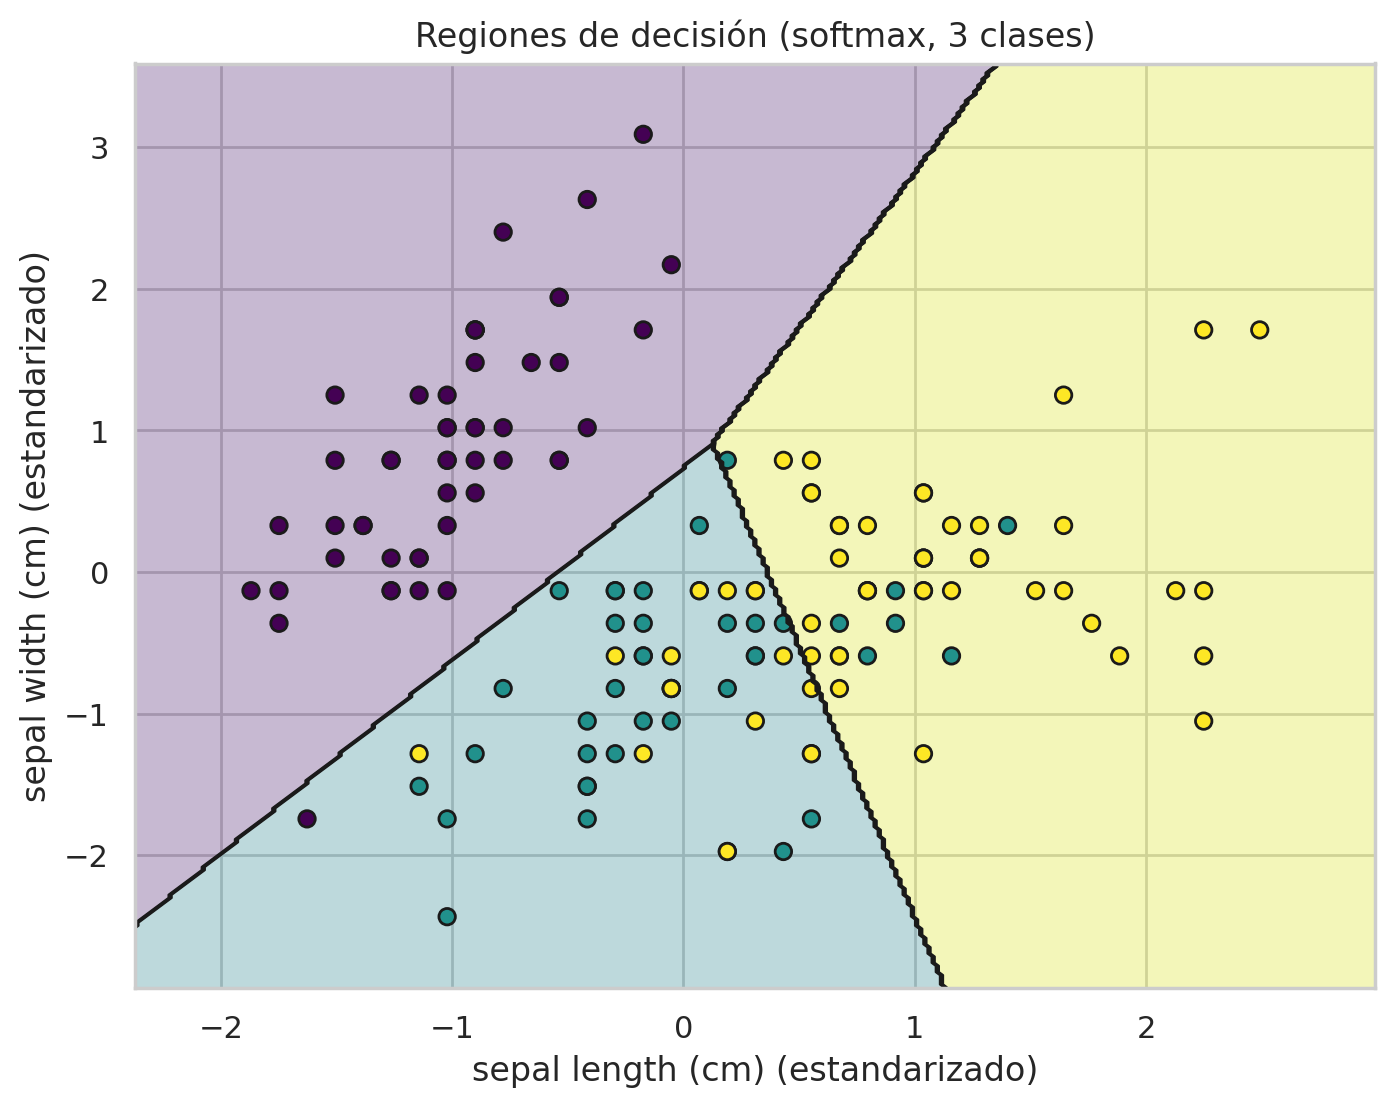

coef_ tiene forma (K clases, p variables): (3, 2)


In [ ]:
# Preprocesado: estandarización de las dos variables (como hará preprocesar_datos en el caso real)
escala = StandardScaler().fit(Xt)
Xt_s = escala.transform(Xt)

lrm = LogisticRegression(max_iter=5000).fit(Xt_s, yt)
xx, yy = np.meshgrid(np.linspace(Xt_s[:,0].min()-.5, Xt_s[:,0].max()+.5, 300),
                     np.linspace(Xt_s[:,1].min()-.5, Xt_s[:,1].max()+.5, 300))
Z = lrm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=.3, cmap='viridis')
plt.contour(xx, yy, Z, colors='k', linewidths=.8)
plt.scatter(Xt_s[:,0], Xt_s[:,1], c=yt, cmap='viridis', edgecolor='k', s=35)
plt.xlabel(iris.feature_names[0] + ' (estandarizado)')
plt.ylabel(iris.feature_names[1] + ' (estandarizado)')
plt.title('Regiones de decisión (softmax, 3 clases)')
plt.show()
print('coef_ tiene forma (K clases, p variables):', lrm.coef_.shape)

El plano queda dividido en **tres regiones** separadas por **fronteras lineales** (rectas a trozos: cada par de clases comparte una). La especie 0 se separa limpiamente; las clases 1 y 2 se solapan y ahí están los errores, como anticipaba el descriptivo. El atributo `coef_` tiene forma $(3,2)$: **un vector de coeficientes por clase**.

# <font color="steelblue">7. Regresión logística multiclase en scikit-learn</font>

Se usa la **misma** clase `LogisticRegression`: al detectar más de dos clases en `y`, ajusta automáticamente el modelo **multinomial** (con los solvers compatibles). Para forzar **One-vs-Rest** se envuelve en `sklearn.multiclass.OneVsRestClassifier`. El resto es idéntico al binario: `predict`, `predict_proba` (una columna por clase, suman 1), `coef_` de forma $(K,p)$, y las métricas se promedian entre clases (`weighted`).

# <font color="steelblue">8. Aplicación: reconocimiento de vinos</font>

El conjunto *Wine* describe **178 vinos** de **3 cultivares** mediante 13 variables químicas.

In [2]:
from sklearn.datasets import load_wine
wine = pd.concat([load_wine(as_frame=True).data, load_wine(as_frame=True).target], axis=1)
wine['target'] = wine['target'].astype('category')
print('Dimensiones:', wine.shape)

Dimensiones: (178, 14)


## <font color="steelblue">8.1. Análisis descriptivo del target y de las predictoras</font>

Miramos primero el **equilibrio de las clases** y después **qué variables separan mejor los cultivares**. Con 3 clases, una buena medida de separación es el **estadístico F de un ANOVA** (`f_classif`): cuanto mayor, más difieren las medias de la variable entre clases.

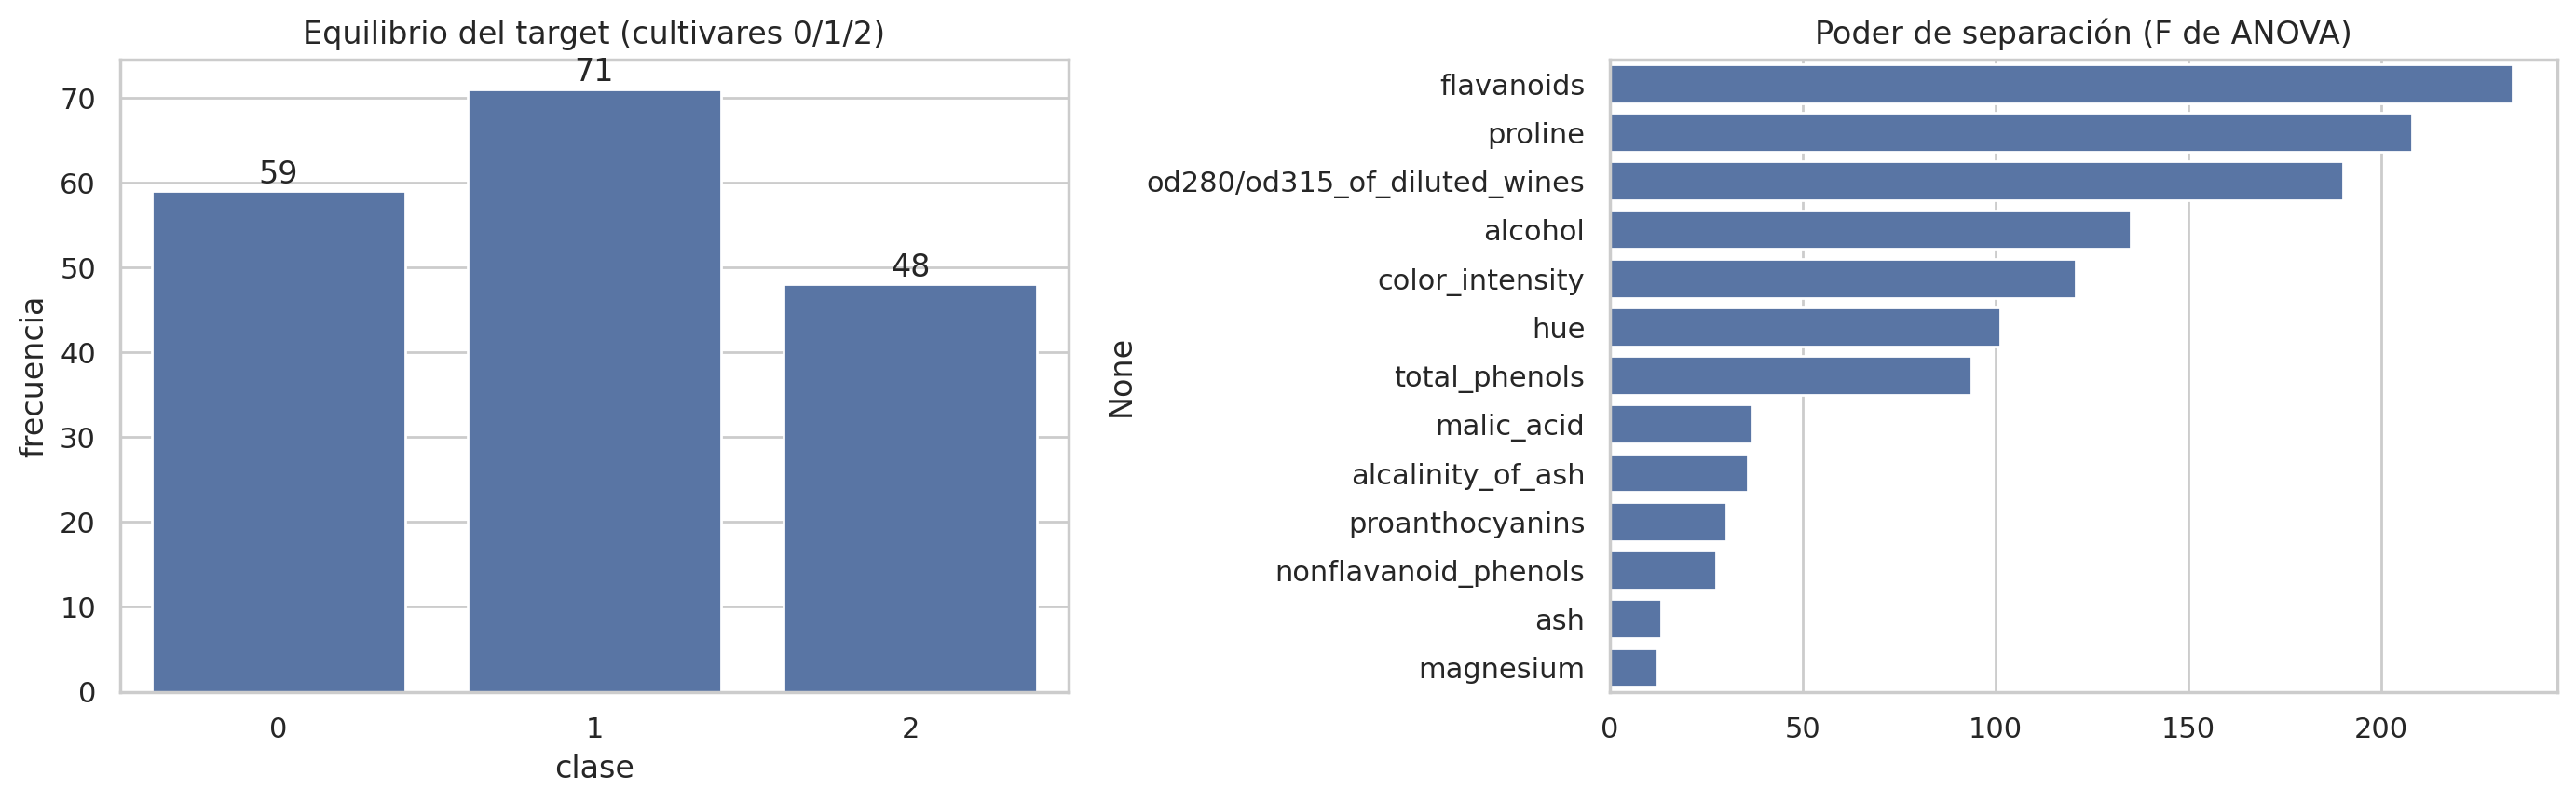

Proporción por clase: {0: 0.331, 1: 0.399, 2: 0.27}


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
conteo = wine['target'].value_counts().sort_index()
sns.barplot(x=conteo.index.astype(str), y=conteo.values, ax=ax[0])
for i, v in enumerate(conteo.values): ax[0].text(i, v+1, str(v), ha='center')
ax[0].set_title('Equilibrio del target (cultivares 0/1/2)')
ax[0].set_xlabel('clase')
ax[0].set_ylabel('frecuencia')

Xn = wine.drop('target', axis=1)
yn = wine['target']
F, _ = f_classif(Xn, yn)
Fserie = pd.Series(F, index=Xn.columns).sort_values(ascending=False)
sns.barplot(x=Fserie.values, y=Fserie.index, ax=ax[1])
ax[1].set_title('Poder de separación (F de ANOVA)')
plt.tight_layout()
plt.show()
print('Proporción por clase:', (wine['target'].value_counts(normalize=True).sort_index().round(3)).to_dict())

Las clases están **moderadamente desbalanceadas** (≈33 % / 40 % / 27 %): no es grave, pero conviene usar métricas robustas (F1 ponderado) más que la *accuracy* sola. Las variables con mayor **F** (*flavanoids*, *proline*, *od280/od315*, *alcohol*, *color_intensity*) son las que **más distinguen** los cultivares. Lo vemos con boxplots de las cuatro principales.

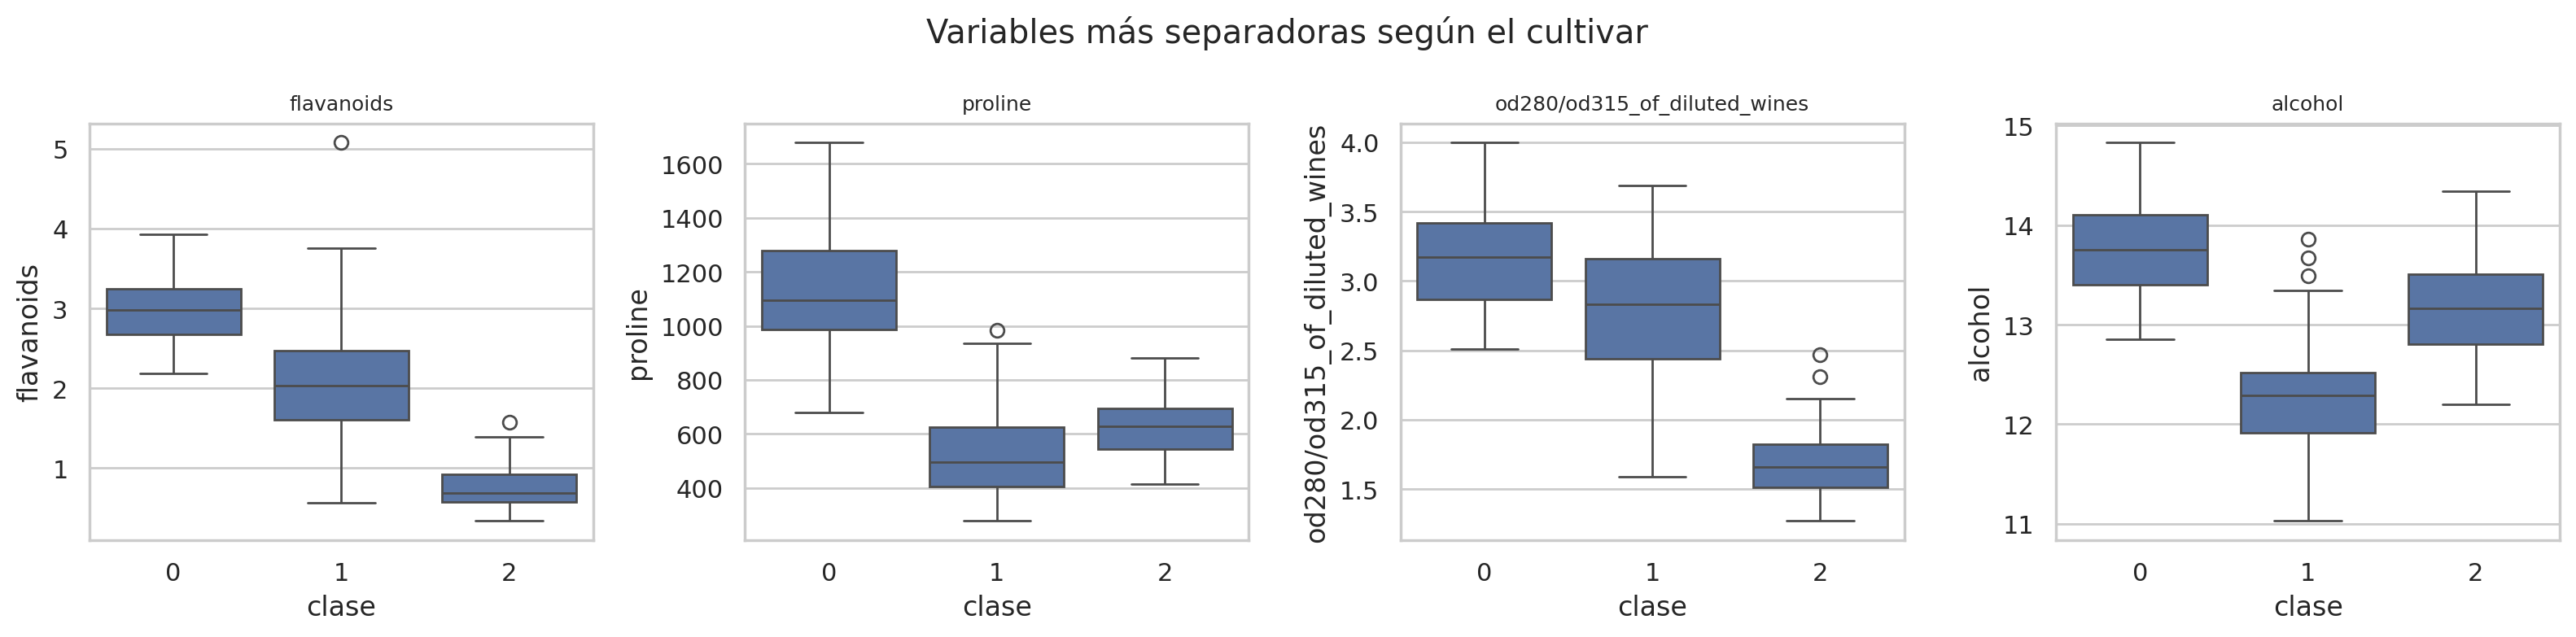

In [4]:
top4 = Fserie.index[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for a, var in zip(axes, top4):
    sns.boxplot(x='target', y=var, data=wine, ax=a)
    a.set_title(var, fontsize=9)
    a.set_xlabel('clase')
plt.suptitle('Variables más separadoras según el cultivar')
plt.tight_layout()
plt.show()

**Interpretación.** En estas variables, los tres cultivares ocupan **rangos distintos** (las cajas se desplazan de una clase a otra), confirmando que el problema es **muy separable**: un modelo lineal debería clasificar casi sin error.

## <font color="steelblue">8.2. Preprocesado y división de muestras</font>

Dividimos primero (estratificando por el target) y **después** preprocesamos, ajustando el preprocesador **solo con el entrenamiento** y aplicándolo al test.

In [5]:
strain_raw, stest_raw = split_sample(wine, 'target', 0.2, 123, True)
strain, prep = preprocesar_datos(strain_raw, 'target')
stest,  _    = preprocesar_datos(stest_raw,  'target', prep)
xtrain, ytrain = strain.drop('target', axis=1), strain['target']
xtest,  ytest  = stest.drop('target', axis=1),  stest['target']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'target'.
  Entrenamiento: 142 muestras | Test: 36 muestras
Entrenamiento: (142, 13) | Test: (36, 13)


## <font color="steelblue">8.3. Modelo base y coeficientes por clase</font>

Entrenamos el modelo por defecto y mostramos sus coeficientes `coef_` $(3,13)$ de dos formas complementarias: como **mapa de radar** (visión global rápida) y como **tabla** (valores exactos, para leer e interpretar cada efecto).

En primer lugar introducimos la función para el gráfico de radar y mostramos su resultado sobre le modelo entrenado.

In [8]:
#@title Función para gráfico radar
def make_radar_chart(df, title, figsize=(8, 8)):
    # Number of variables
    categories = list(df.columns)
    N = len(categories)

    # We are going to plot each row of the dataframe as a line
    # The 'values' for each line must be a list of values, for each category.
    # We need to close the circle, so we concatenate the first value at the end.
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], categories, color='grey', size=12)

    # Draw ylabels
    ax.set_rlabel_position(0)
    ax.tick_params(axis='y', colors='grey') # Set color of radial ticks
    plt.yticks(color="grey", size=8)
    plt.ylim(df.min().min() * 1.1, df.max().max() * 1.1) # Dynamic y-limits

    for i, (name, row) in enumerate(df.iterrows()):
        values = row.tolist()
        values += values[:1] # Close the plot
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=name)

    plt.title(title, size=16, color='steelblue', y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

Veamos su resultado sobre el modelo entrenado:

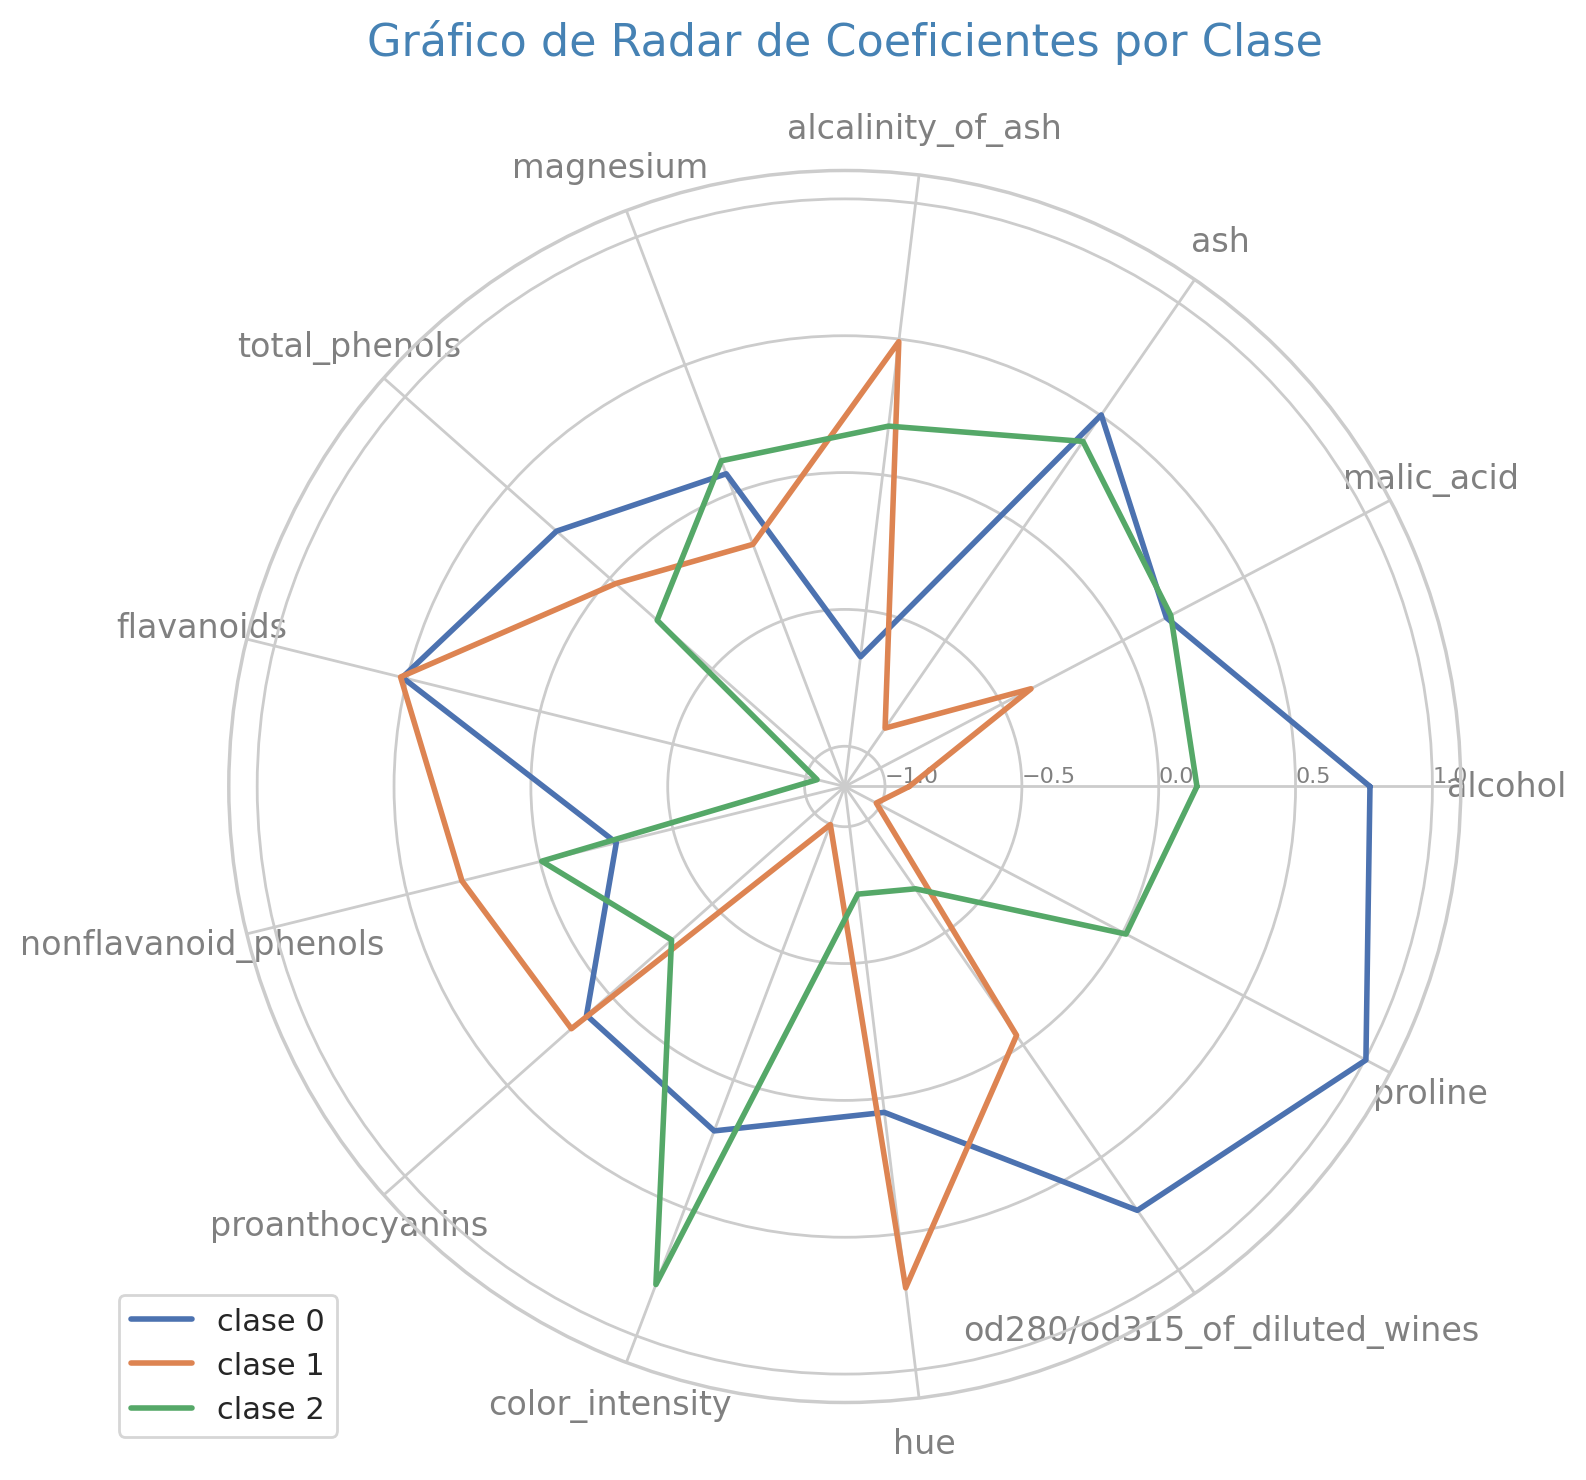

In [9]:
make_radar_chart(coefs, 'Gráfico de Radar de Coeficientes por Clase')

El gráfico de radar visualiza los coeficientes del modelo modelo para cada una de las clases, permitiendo una interpretación rápida del "perfil" de cada cultivar:

* Cada eje (radial) representa una de las características (variables) de los vinos (por ejemplo, 'alcohol', 'flavanoids', 'proline', etc.).
* Cada línea de color corresponde a una de las clases (cultivares) del vino (clase 0, clase 1, clase 2).
* La posición de cada punto en un eje indica la magnitud del coeficiente de esa característica para esa clase. Un valor más alejado del centro (mayor magnitud) significa que esa característica tiene una mayor influencia en la probabilidad de que una muestra pertenezca a esa clase.

En general:

* Si la línea de una clase se extiende mucho a lo largo de un eje, significa que esa característica es muy importante para esa clase.
* La dirección (implícita en el valor del coeficiente, aunque no se visualice directamente si son solo magnitudes absolutas o valores que pueden ser negativos y positivos como en este caso) nos diría si la característica aumenta o disminuye la probabilidad de pertenecer a esa clase. Los coeficientes positivos en una clase impulsan hacia esa clase, mientras que los negativos la alejan.

Al observar el gráfico, puedes identificar rápidamente qué variables son distintivas para cada clase. Por ejemplo, si una clase tiene una 'punta' muy pronunciada en un eje específico y las otras clases tienen un valor bajo o cercano al centro en ese mismo eje, esa característica es clave para diferenciar esa clase de las demás.

In [15]:
# Tabla de coeficientes (variables en filas, clases en columnas) e intercepto
tabla_coef = coefs.T.copy()
tabla_coef.columns = [f'coef_{c}' for c in modelo.classes_]
print('Interceptos por clase:', dict(zip([f'clase {c}' for c in modelo.classes_], np.round(modelo.intercept_, 3))))
tabla_coef.round(3)

Interceptos por clase: {'clase 0': np.float64(0.312), 'clase 1': np.float64(0.644), 'clase 2': np.float64(-0.956)}


,coef_0,coef_1,coef_2
alcohol,0.772,-0.912,0.140
malic_acid,0.180,-0.378,0.198
ash,0.503,-0.888,0.385
alcalinity_of_ash,-0.670,0.490,0.179
magnesium,0.075,-0.201,0.126
total_phenols,0.260,-0.029,-0.231
flavanoids,0.518,0.525,-1.043
nonflavanoid_phenols,-0.287,0.294,-0.007
proanthocyanins,0.114,0.188,-0.301
color_intensity,0.199,-0.998,0.799


Esta tabla muestra los coeficientes de regresión logística para cada una de las 13 características (filas) y para cada una de las 3 clases de vino (columnas: coef_0, coef_1, coef_2). Recuerda que las variables ya han sido estandarizadas, lo que permite comparar la magnitud de los coeficientes entre ellas.

¿Cómo interpretar los valores?

* Signo del coeficiente (+ o -):

  * Un coeficiente positivo (por ejemplo, alcohol para coef_0 es 0.772) indica que, a medida que aumenta el valor de esa característica, la probabilidad de que la muestra pertenezca a esa clase específica (en este caso, la clase 0) aumenta.
  * Un coeficiente negativo (por ejemplo, alcohol para coef_1 es -0.912) indica que, a medida que aumenta el valor de esa característica, la probabilidad de que la muestra pertenezca a esa clase específica (en este caso, la clase 1) disminuye.

Magnitud del coeficiente (valor absoluto):

  * Un coeficiente con un valor absoluto grande (por ejemplo, flavanoids para coef_2 es -1.043, y proline para coef_1 es -1.017) sugiere que esa característica tiene una fuerte influencia en la determinación de si una muestra pertenece o no a esa clase. Cuanto mayor es el valor absoluto, mayor es la importancia de la característica para esa clase.
  * Un coeficiente con un valor absoluto pequeño (por ejemplo, nonflavanoid_phenols para coef_2 es -0.007) indica que esa característica tiene una influencia muy baja o casi nula en la predicción de esa clase.

En resumen, al mirar la tabla se puede identificar fácilmente:

* Características distintivas por clase: Las variables con coeficientes positivos grandes para una clase y negativos grandes para otras son clave para diferenciar esa clase.
* Características que 'penalizan' una clase: Variables con coeficientes negativos importantes para una clase.

Por ejemplo:

* La característica proline tiene un coeficiente positivo fuerte para la clase 0 (1.003) y un negativo fuerte para la clase 1 (-1.017), lo que indica que un alto contenido de proline es un buen indicador de la clase 0 y un fuerte desincentivo para la clase 1.
* La color_intensity es un predictor negativo fuerte para la clase 1 (-0.998) y positivo para la clase 2 (0.799), sugiriendo que un valor alto en esta característica es más probable que corresponda a la clase 2 y menos probable a la clase 1.

También podemos expresar cada coeficiente como **odds ratio** ($e^{w_{kj}}$): cuánto se multiplican los odds de pertenecer a esa clase (frente al resto) al aumentar la variable una unidad estandarizada.

In [16]:
tabla_odds = np.exp(coefs.T)
tabla_odds.columns = [f'OR_{c}' for c in modelo.classes_]
tabla_odds.round(3)

,OR_0,OR_1,OR_2
alcohol,2.164,0.402,1.150
malic_acid,1.197,0.685,1.219
ash,1.653,0.412,1.470
alcalinity_of_ash,0.512,1.633,1.196
magnesium,1.078,0.818,1.134
total_phenols,1.297,0.972,0.794
flavanoids,1.679,1.690,0.352
nonflavanoid_phenols,0.750,1.341,0.993
proanthocyanins,1.120,1.206,0.740
color_intensity,1.220,0.369,2.224


La tabla_odds muestra el odds ratio para cada característica y clase. Cada valor indica cuánto se multiplican las probabilidades (odds) de pertenecer a una clase específica (frente al resto) cuando esa característica aumenta en una unidad estandarizada.

* Valores > 1: La característica aumenta las probabilidades de que una muestra pertenezca a esa clase.
* Valores < 1: La característica disminuye las probabilidades de que una muestra pertenezca a esa clase.

En resumen, cuanto más lejos de 1 esté el valor, mayor es la influencia de esa característica en la predicción de la clase.

## <font color="steelblue">8.4. Evaluación y validación del modelo</font>

Dado el desbalanceo moderado, usamos el **F1 ponderado** (`f1_weighted`), que promedia el F1 de cada clase ponderando por su frecuencia: combina *precision* y *recall* y no se deja engañar por la clase mayoritaria. Analizamos cada herramienta y damos una valoración global.

**(a) Informe de clasificación.** Da *precision*, *recall* y *f1* **por clase** en entrenamiento y test. Buscamos que el test sea alto y **parecido** al entrenamiento (señal de que no sobreajusta).

In [17]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



**(b) Matriz de confusión.** En este test la diagonal está al **100 %**: el modelo clasifica **correctamente los tres cultivares sin un solo error**. Que aquí no haya errores confirma que el problema es muy separable; pero —ojo— un resultado **perfecto en un único test** puede depender de la partición concreta, por lo que la **validación cruzada** es la que da la medida fiable.

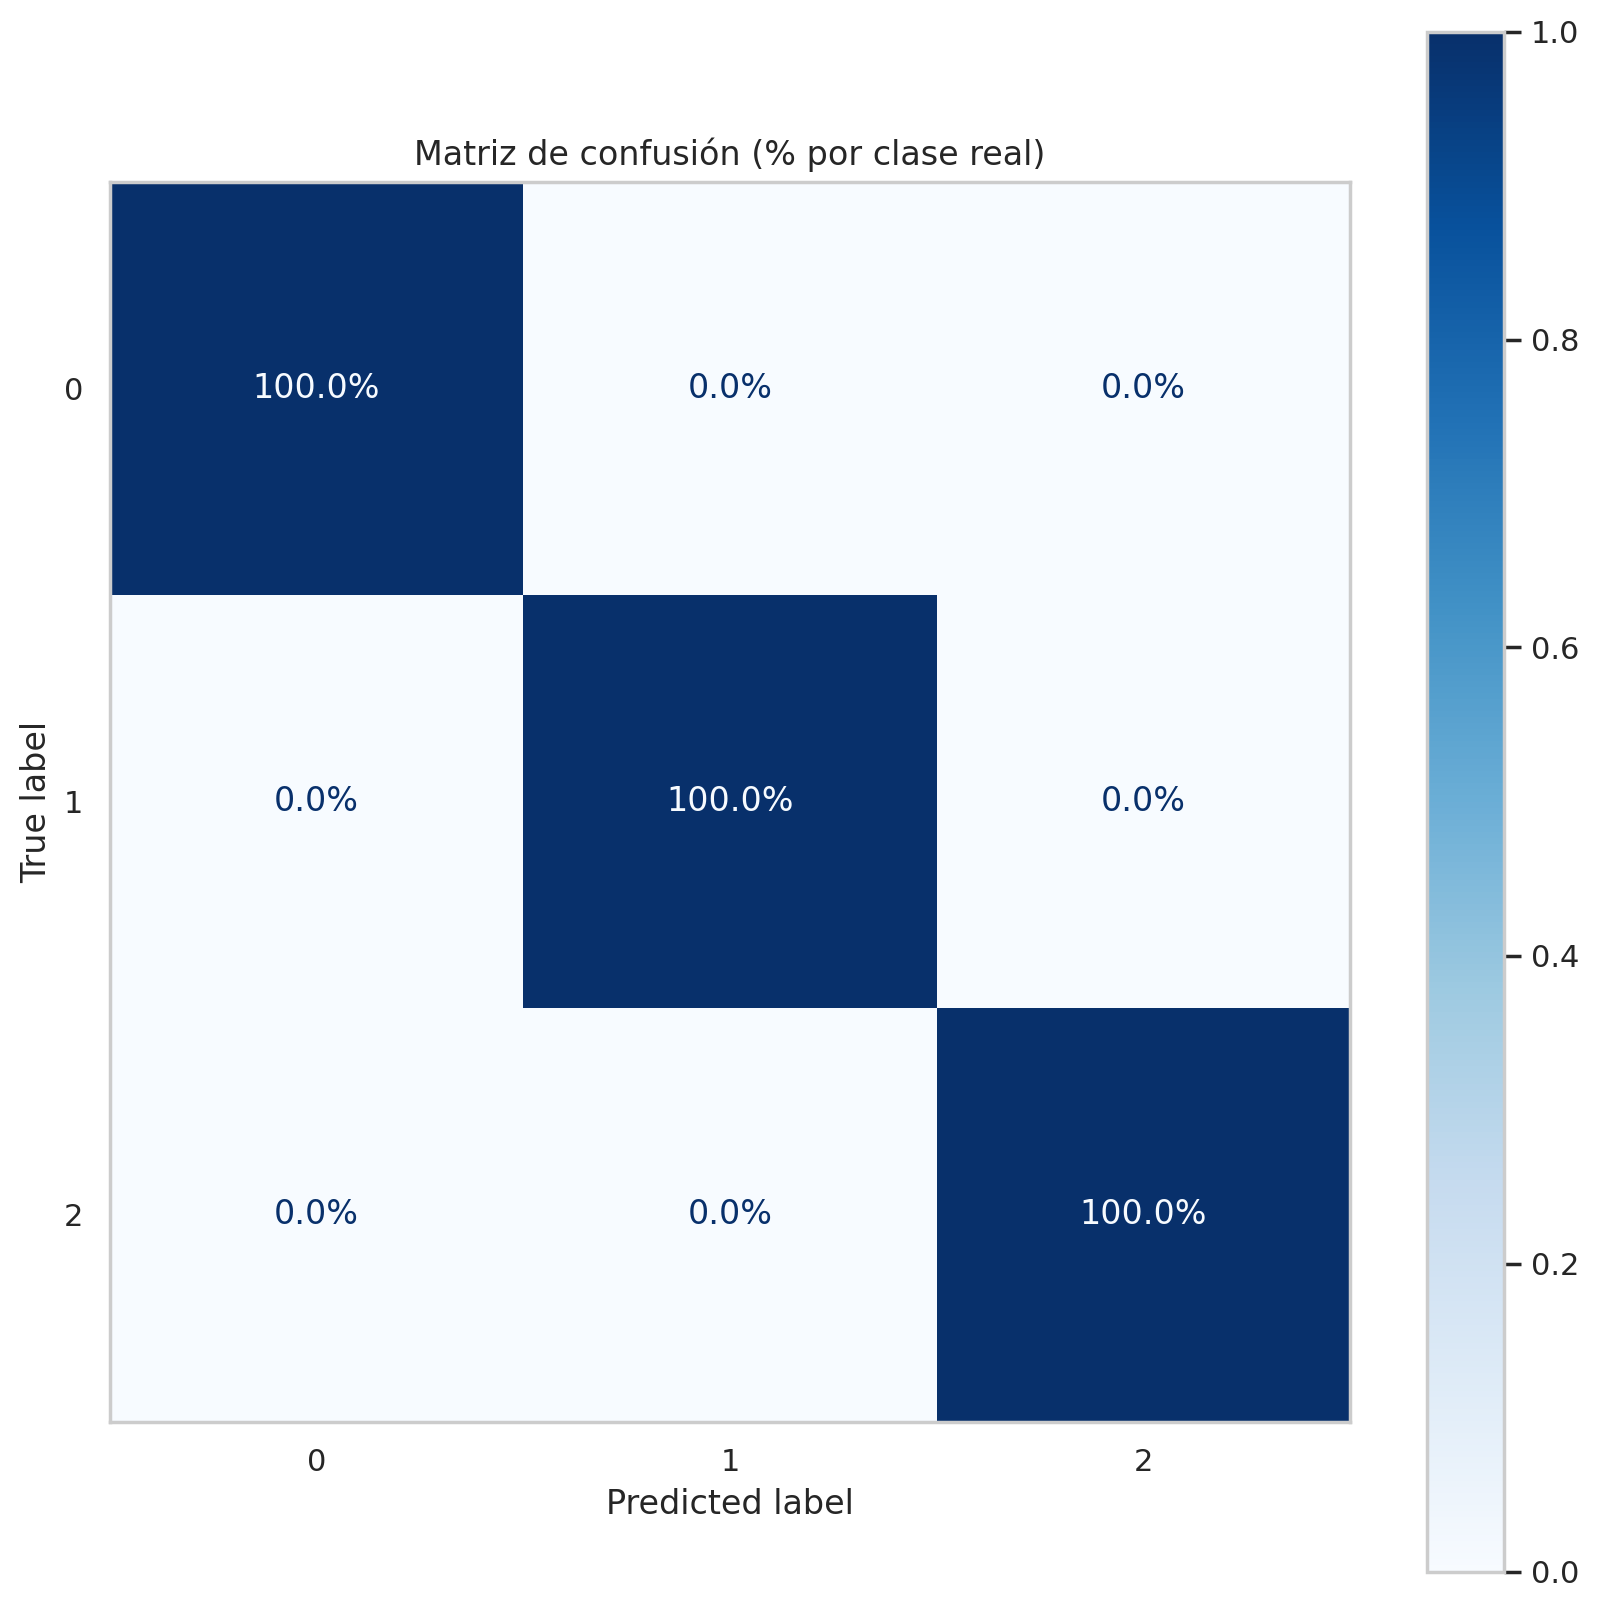

In [18]:
cm = matriz_confusion(modelo, xtest, ytest);

**(c) Validación cruzada.** Tomamos 5 folds y reportammos el F1 ponderado **medio ± desviación**. Aquí el medio (~0.98) es **algo inferior** al 100 % del test único: revela que, en algunas particiones, el modelo **sí** comete alguna confusión (normalmente entre las clases 1 y 2). Es la cifra **honesta** del rendimiento. La desviación pequeña indica que la solución es **estable**.

In [19]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1_weighted', 5)

Validacion cruzada (5 folds, score=f1_weighted): media = 0.986 +/- 0.017


**(d) Curva de aprendizaje.** Muestra el F1 en **entrenamiento** (azul) y **validación** (rojo) según crece el número de muestras. Ambas curvas quedan **altas y muy juntas**, con brecha pequeña: el modelo tiene **poco sesgo** (nivel alto) y **poca varianza** (poca brecha), es decir, **generaliza bien** y no necesitaría muchos más datos.

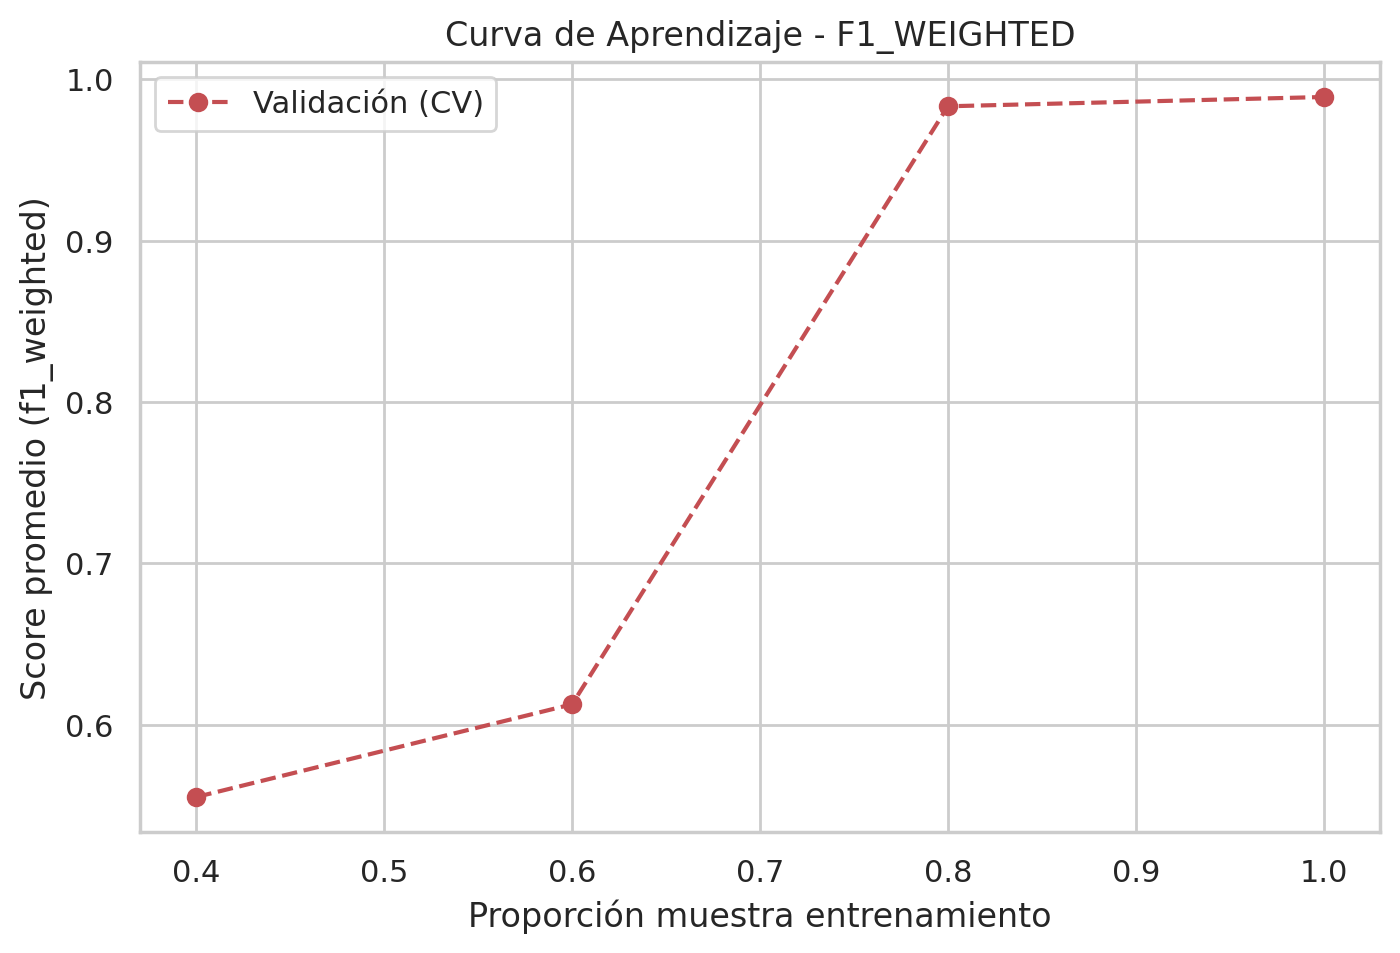

In [20]:
datos_pp, _ = preprocesar_datos(wine, 'target')
X = datos_pp.drop('target', axis=1)
y = datos_pp['target']
curva_aprendizaje(modelo, X, y, 'f1_weighted', 5)



**Valoración global.** Informe, matriz de confusión, validación cruzada y curva de aprendizaje son **coherentes**: un modelo lineal sencillo clasifica los tres cultivares con un F1 ≈ 0.98 **estable**. El test perfecto matiza con la validación cruzada (las clases 1–2 se confunden ocasionalmente). Veamos si se puede **simplificar**.

## <font color="steelblue">8.5. Selección de características</font>

La **eliminación recursiva (RFE)** busca el subconjunto de variables que maximiza el F1 ponderado por validación cruzada.

In [14]:
scores_df, variables, k_best, score_best = select_variables(
    LogisticRegression(max_iter=5000), X, y, range(1, X.shape[1]+1), 'f1_weighted', folds=5)

print(f"k óptimo: {k_best}  |  f1_weighted: {score_best:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(scores_df.k, scores_df.score, 'o--', color='r')
plt.axvline(k_best, color='blue', ls='--')
plt.xlabel('nº de variables (k)')
plt.ylabel('f1_weighted (validación cruzada)')
plt.title('Selección de variables por RFE')
plt.grid(True)
plt.show()
scores_df.round(4)

NameError: name 'X' is not defined

**Interpretación: hacia un modelo más parsimonioso.** La curva **sube rápido y se aplana**: con solo **8 variables** el F1 ya es ≈ **0.983**, casi igual que con las **13** (≈ 0.989). De nuevo, lo relevante es el **rango de valores**: una solución con ~8 predictoras rinde prácticamente igual y es **más simple e interpretable**. Construimos ese modelo y lo evaluamos.

## <font color="steelblue">8.6. Preprocesado con componentes principales (PCA)</font>

Como **todas las predictoras son numéricas** (y están estandarizadas), reducimos la dimensión con **PCA** y nos quedamos con las componentes necesarias para explicar **≥ 70 %** de la variabilidad.

Componentes para ≥70% de varianza: 4  (varianza acumulada = 74.4%)


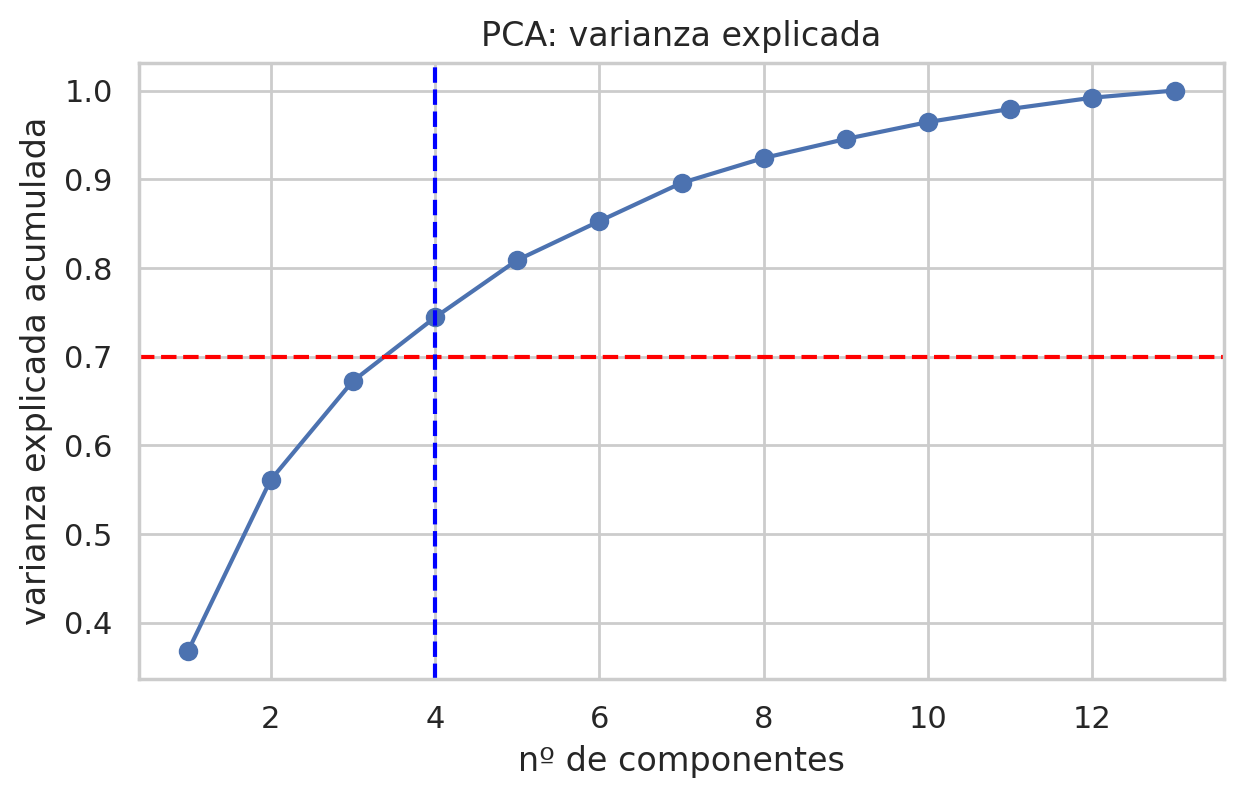

In [21]:
pca_full = PCA().fit(xtrain)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k70 = int(np.argmax(var_acum >= 0.70) + 1)
print(f'Componentes para ≥70% de varianza: {k70}  (varianza acumulada = {var_acum[k70-1]:.1%})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_acum)+1), var_acum, 'o-')
plt.axhline(0.70, color='red', ls='--')
plt.axvline(k70, color='blue', ls='--')
plt.xlabel('nº de componentes')
plt.ylabel('varianza explicada acumulada')
plt.title('PCA: varianza explicada')
plt.show()

Visualizamos las **dos primeras componentes** coloreadas por el cultivar para analizar **visualmente** el poder de clasificación.

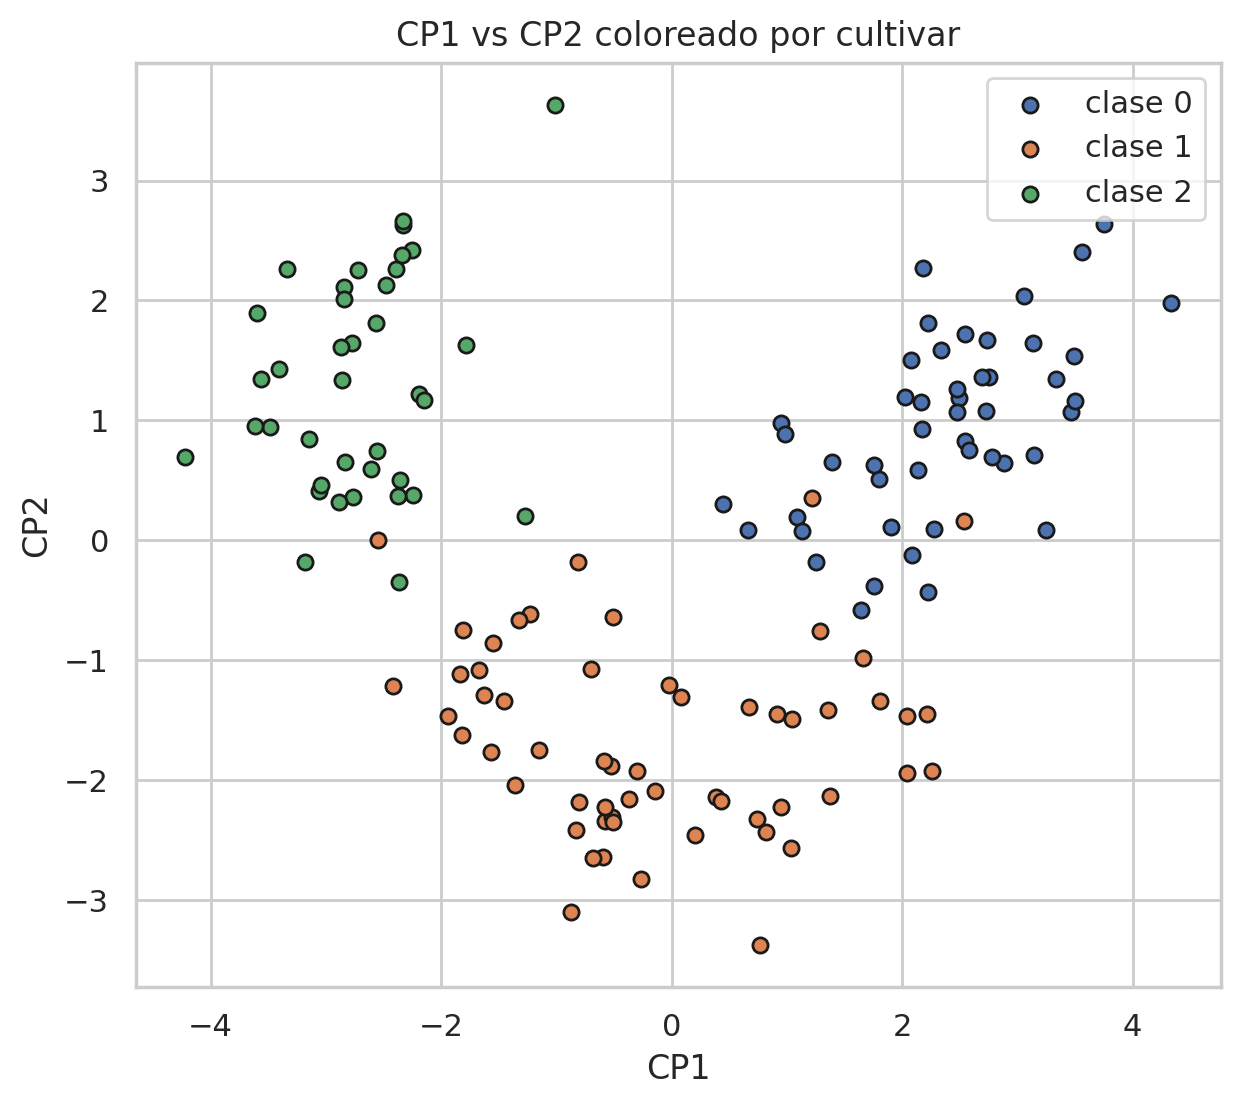

In [22]:
pca = PCA(n_components=k70).fit(xtrain)
Xtr_pca = pca.transform(xtrain); Xte_pca = pca.transform(xtest)

plt.figure(figsize=(7, 6))
for c in sorted(ytrain.unique()):
    mask = ytrain.values == c
    plt.scatter(Xtr_pca[mask, 0], Xtr_pca[mask, 1], label=f'clase {c}', edgecolor='k', s=30)
plt.xlabel('CP1')
plt.ylabel('CP2')
plt.legend()
plt.title('CP1 vs CP2 coloreado por cultivar')
plt.show()

En el plano **CP1–CP2** los tres cultivares aparecen en **zonas bien diferenciadas** (con un solape menor entre dos de ellos): solo dos componentes ya separan visualmente las clases, lo que anticipa que un modelo sobre las componentes funcionará bien. Lo entrenamos sobre las `k70` componentes y lo evaluamos.

In [23]:
modelo_pca = LogisticRegression(max_iter=5000).fit(Xtr_pca, ytrain)
print(f'=== Modelo sobre {k70} componentes principales ===')
print(classification_report(ytest, modelo_pca.predict(Xte_pca), digits=3))

=== Modelo sobre 4 componentes principales ===
              precision    recall  f1-score   support

           0      0.917     0.917     0.917        12
           1      0.929     0.929     0.929        14
           2      1.000     1.000     1.000        10

    accuracy                          0.944        36
   macro avg      0.948     0.948     0.948        36
weighted avg      0.944     0.944     0.944        36



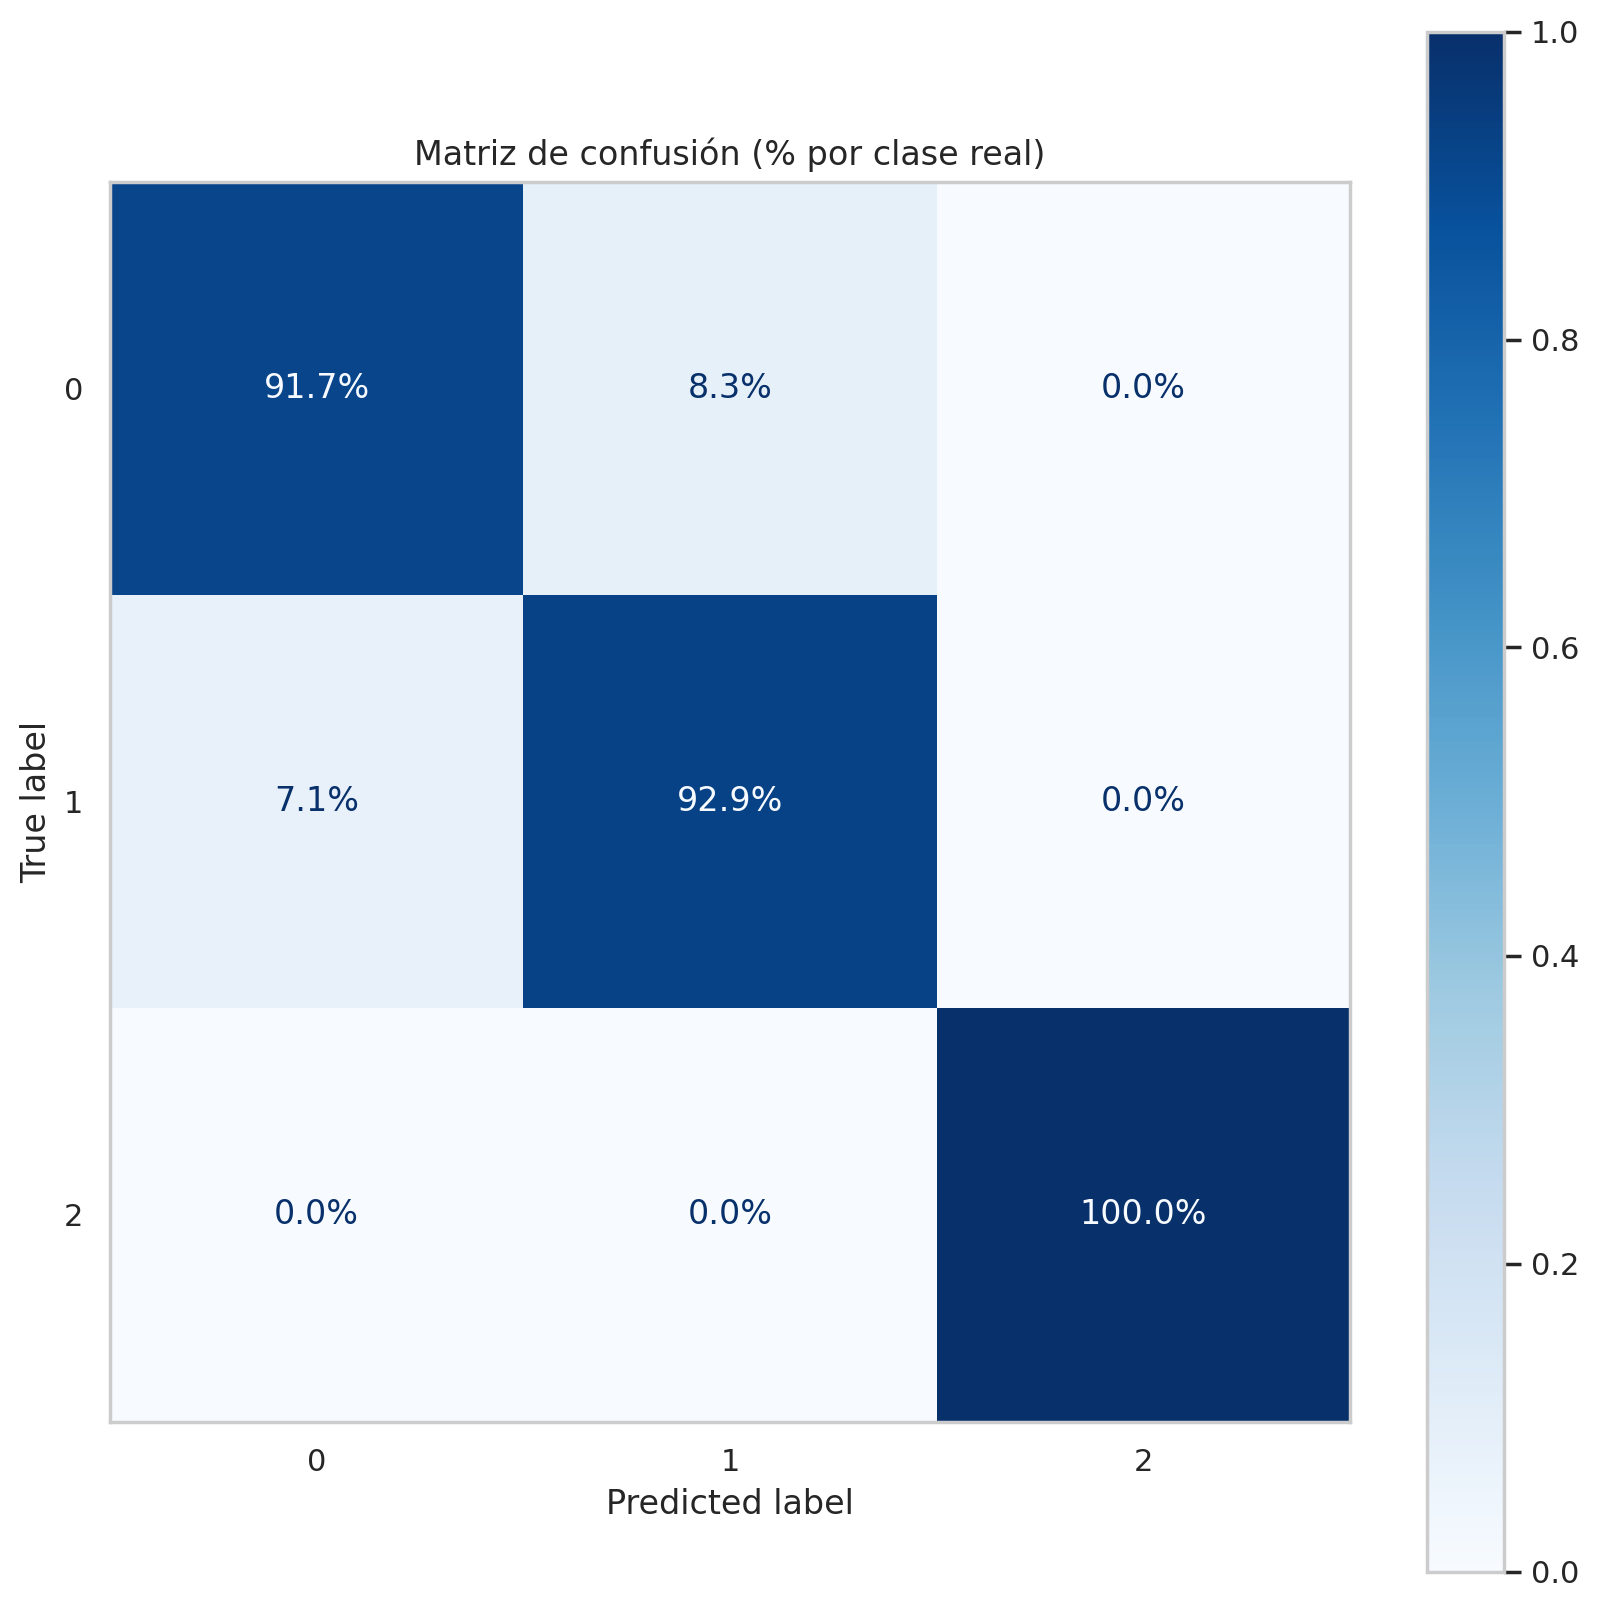

In [24]:
# Matriz de confusión (test) del modelo PCA
matriz_confusion(modelo_pca, Xte_pca, ytest);

In [25]:
# Validación cruzada (f1_weighted) del modelo PCA
val_pca = validar_modelo(modelo_pca, Xtr_pca, ytrain, 'f1_weighted', 5)

Validacion cruzada (5 folds, score=f1_weighted): media = 0.958 +/- 0.015


Con **4 componentes** (≈74 % de la varianza) el modelo alcanza un F1 **alto** (~0.94–0.96), algo por debajo del modelo con las 13 variables. La matriz de confusión revela que las pocas confusiones se dan entre los **cultivares 0 y 1** (los que más se solapaban en el plano CP1–CP2). A cambio de esa ligera pérdida, ganamos **compresión** (de 13 a 4 variables) y una **visualización** directa de la estructura. Como en binaria: **PCA** comprime y visualiza, mientras que la **selección de variables** (8.5) preserva la interpretabilidad química.


# <font color="steelblue">9. Optimización del modelo (hiperparámetros)</font>

Partimos del **modelo base** y buscamos con `GridSearchCV` la mejor combinación de `C`, `penalty` y `solver` (usamos `saga`, que admite `l1` y `l2` en multinomial). Métrica: `f1_weighted`.

In [26]:
pgrid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['saga']}
gs = GridSearchCV(LogisticRegression(max_iter=5000), pgrid, scoring='f1_weighted', cv=5)
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_)
print(f'Mejor f1_weighted (validación cruzada): {gs.best_score_:.4f}')

Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Mejor f1_weighted (validación cruzada): 0.9860


Evaluamos el modelo con la solución óptima.

In [28]:
modelo_opt = gs.best_estimator_
print('=== Modelo OPTIMIZADO ===')
reports_clas(modelo_opt, xtrain, ytrain, xtest, ytest)

=== Modelo OPTIMIZADO ===
Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Como en el modelo de clasificación binaria, cuando el modelo base ya es muy bueno la mejora del F1 es marginal, pero la optimización fija la **regularización adecuada**. En este caso no es posible simplificar el modelo (trabajamos con `l2`).

Analizamos el modelo obtenido:

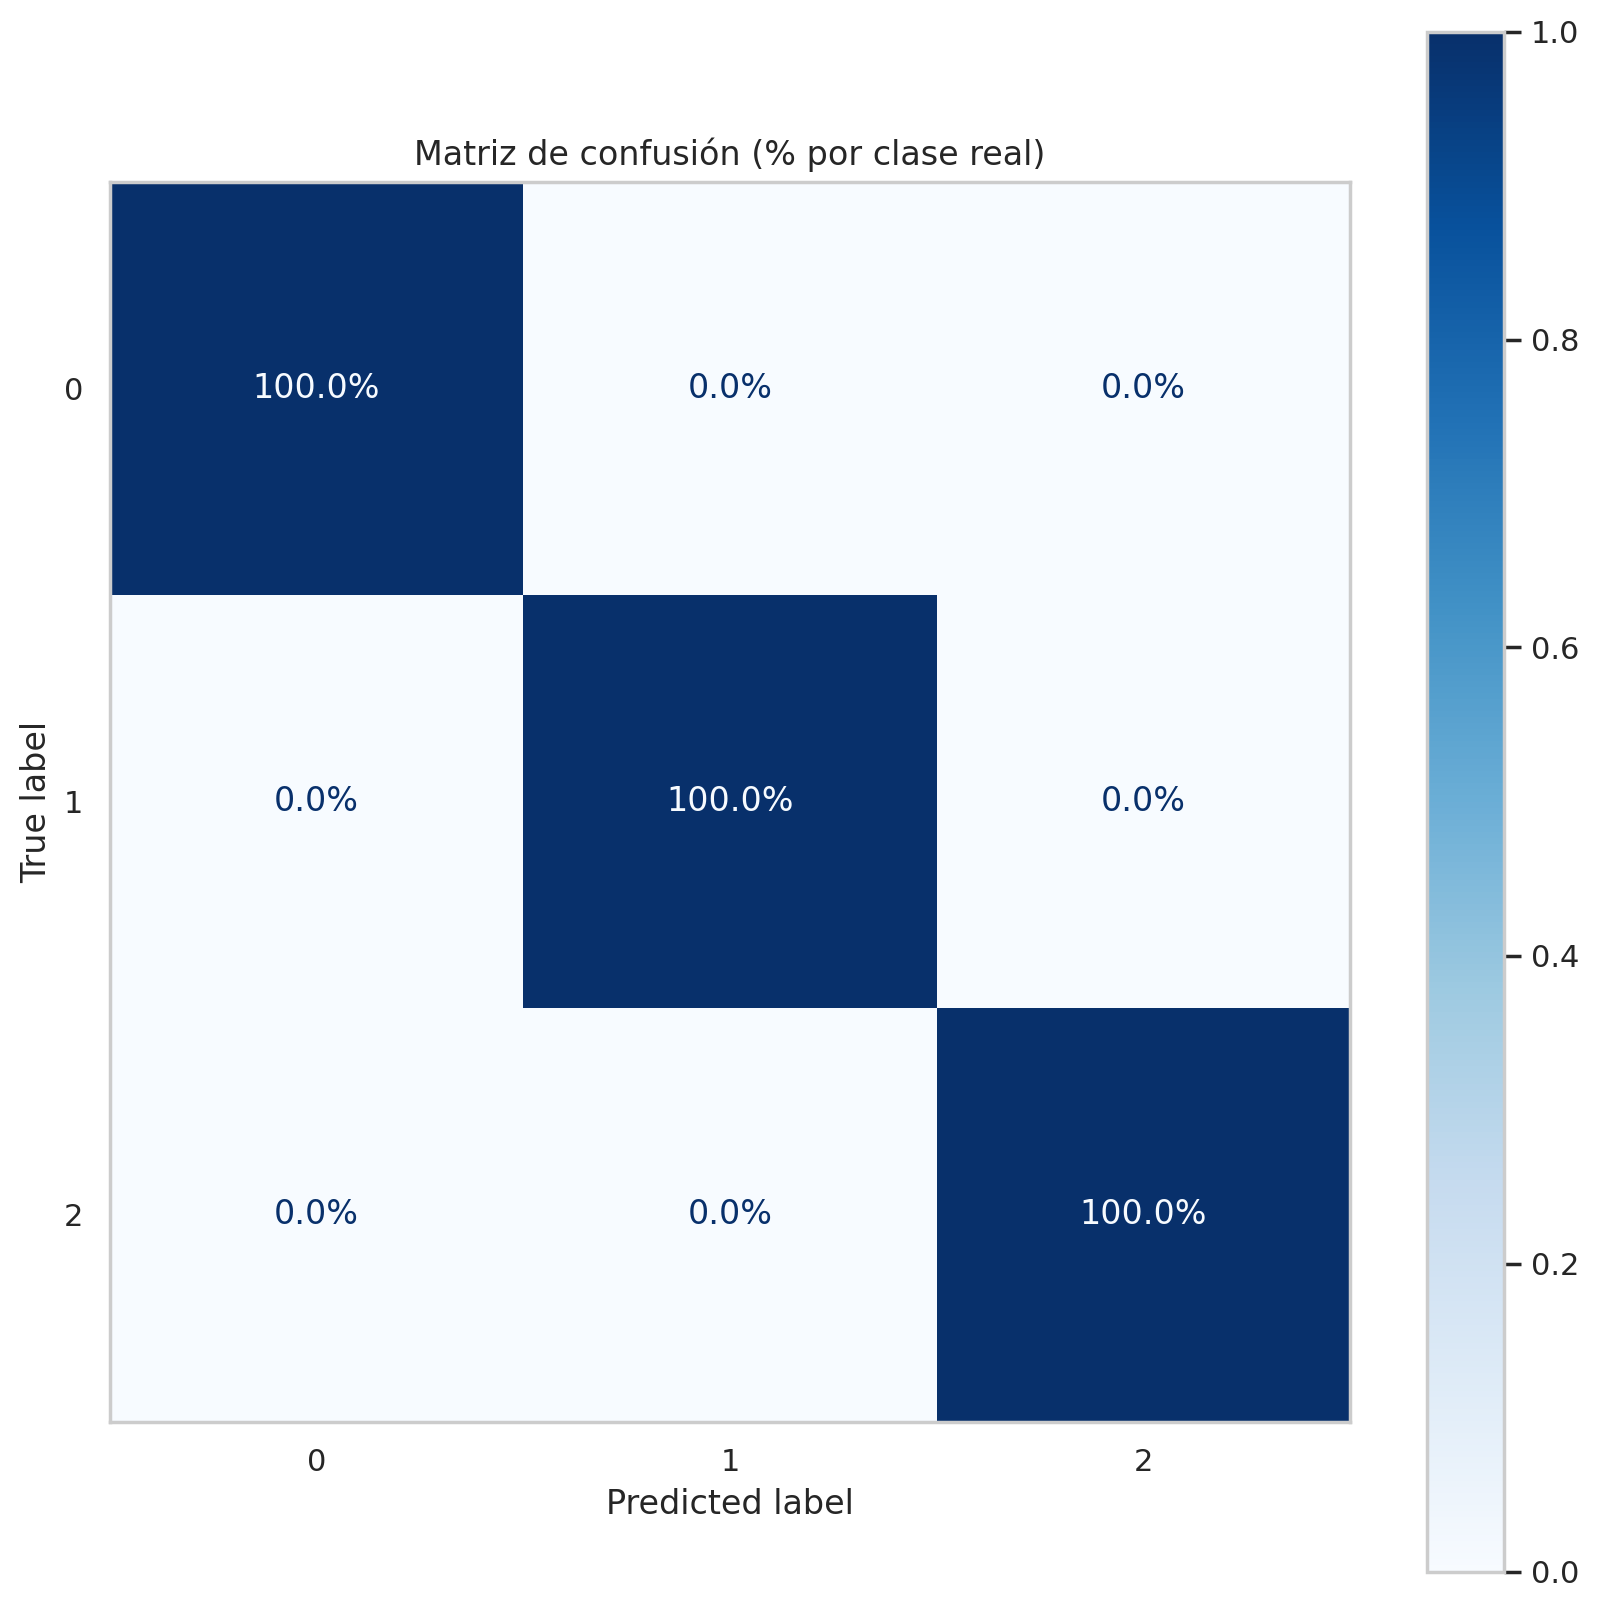

In [29]:
# Matriz de confusión (test) del modelo ponderado
matriz_confusion(modelo_opt, xtest, ytest);

In [30]:
val_bal = validar_modelo(modelo_opt, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.979 +/- 0.046


# <font color="steelblue">10. Corrección del desbalanceo: ponderación de clases</font>

Las clases están algo desbalanceadas (≈33/40/27 %). Para que el modelo no favorezca a la clase mayoritaria, ponderamos con **`class_weight='balanced'`**.

In [31]:
# Entrenamiento del modelo balanceado
modelo_bal = LogisticRegression(max_iter=5000, class_weight='balanced').fit(xtrain, ytrain)
print('=== Modelo con class_weight="balanced" ===')
reports_clas(modelo_bal, xtrain, ytrain, xtest, ytest)

=== Modelo con class_weight="balanced" ===
Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



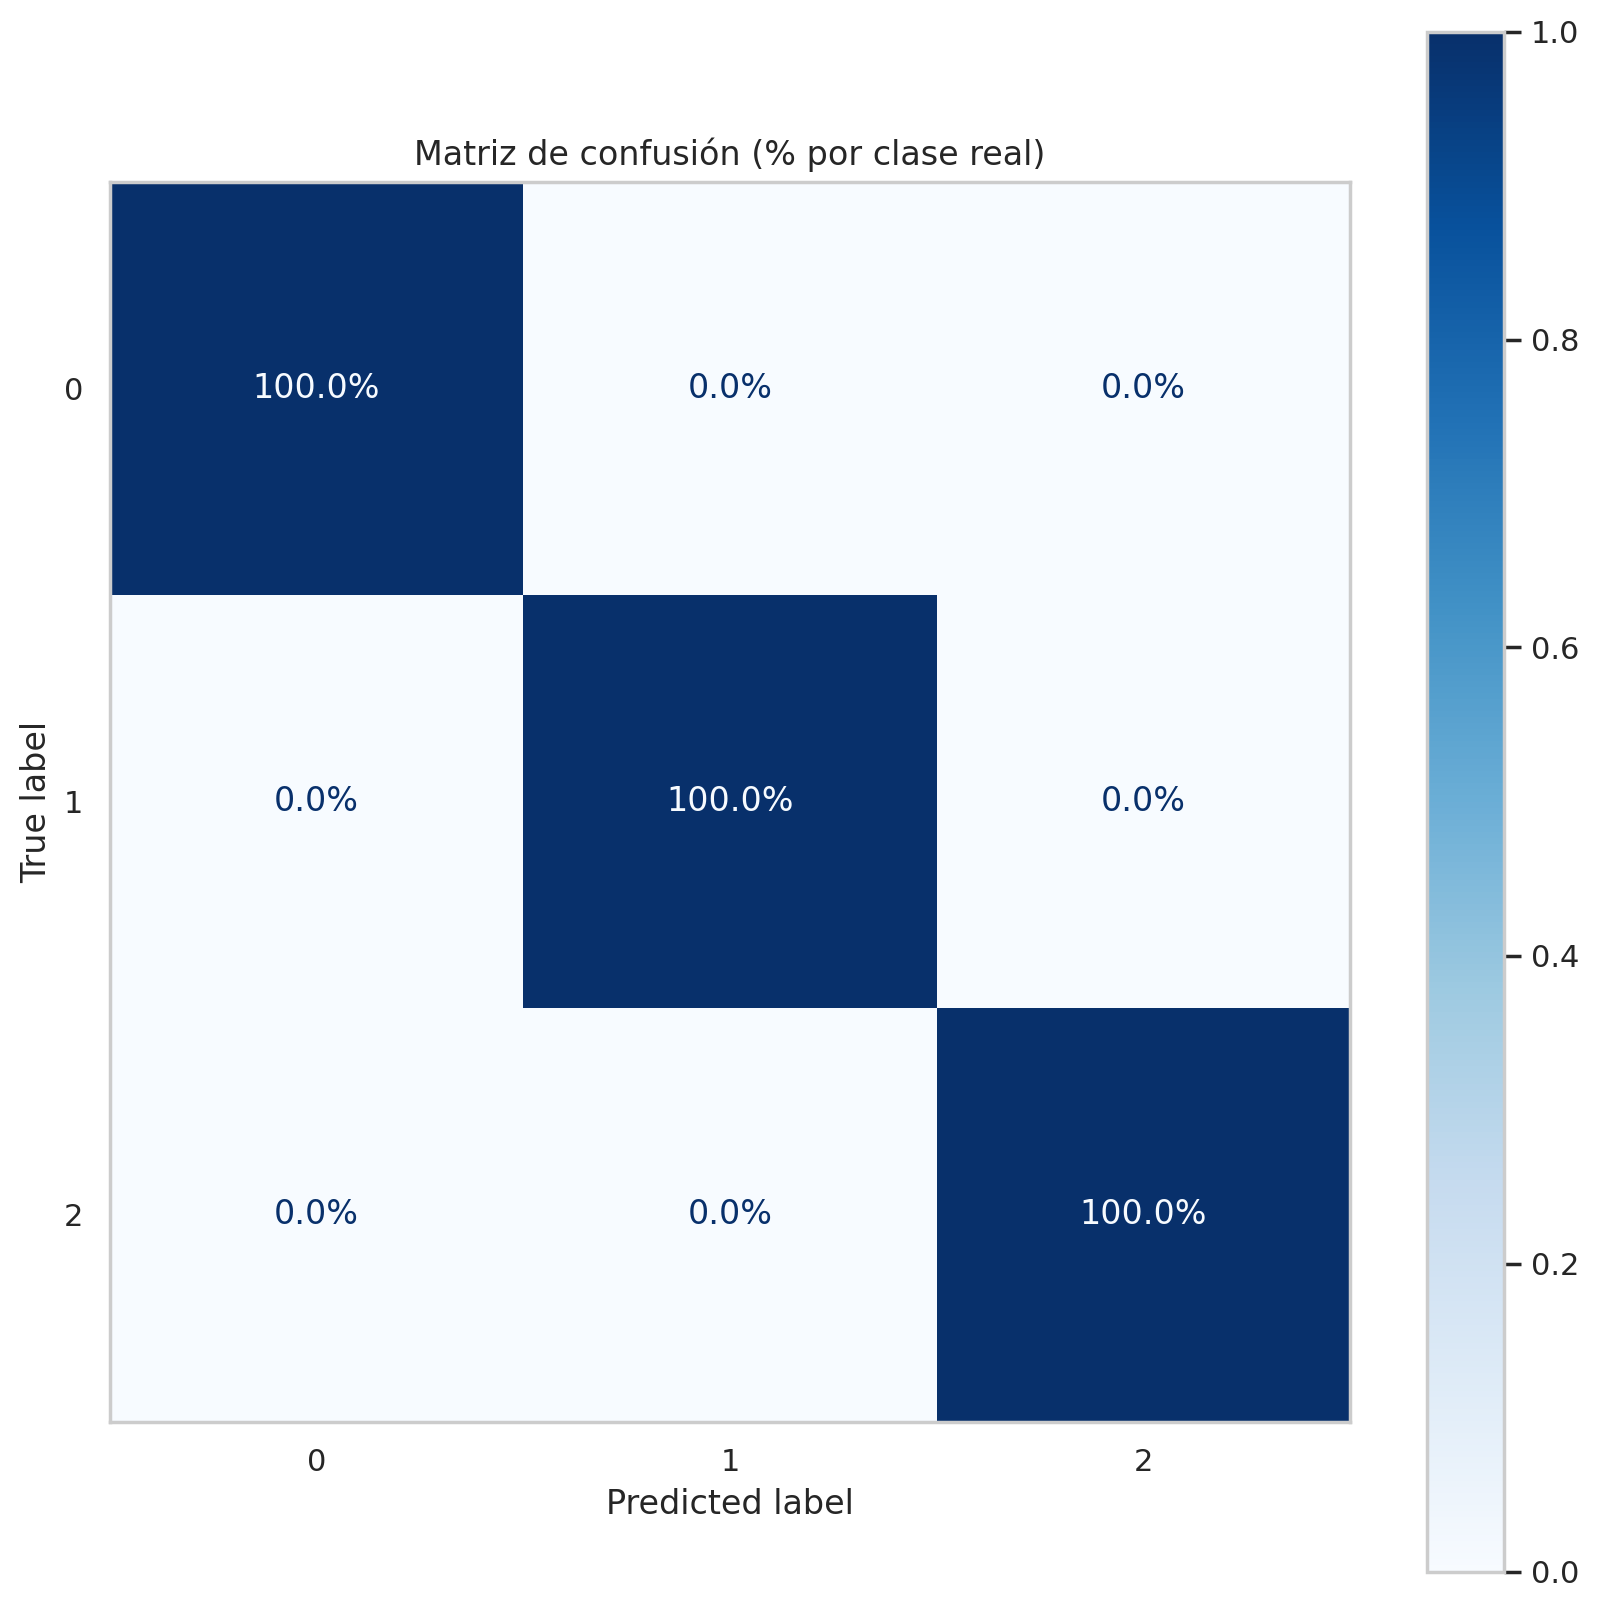

In [32]:
# Matriz de confusión (test) del modelo ponderado
matriz_confusion(modelo_bal, xtest, ytest);

In [33]:
# Validación cruzada (f1_weighted) del modelo ponderado
val_bal = validar_modelo(modelo_bal, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.979 +/- 0.046


La ponderación reequilibra el coste de los errores hacia las clases menos frecuentes (aquí la clase 2). En este conjunto, con desbalanceo **moderado** y clases muy separables, el efecto es **pequeño** pero **ligeramente favorable**: el F1 ponderado de validación cruzada sube un poco (de ~0.978 a ~0.983), porque el modelo presta algo más de atención al cultivar minoritario sin perjudicar a los demás. La regla general se mantiene: la ponderación es **imprescindible con desbalanceo severo** y opcional cuando es leve; si el objetivo es proteger una clase concreta, conviene combinarla con el ajuste del umbral o validar con el *recall* de esa clase.



# <font color="steelblue">11. Segundo ejemplo: dígitos manuscritos</font>

El conjunto *Digits* (1797 imágenes de 8×8 de dígitos 0–9, **10 clases**) es un reto multiclase mayor. Lo preprocesamos, entrenamos el modelo base y vemos su matriz de confusión.

Estratificando por 'target'.
  Entrenamiento: 1437 muestras | Test: 360 muestras
coef_ (K, p): (10, 64) | accuracy test: 0.975


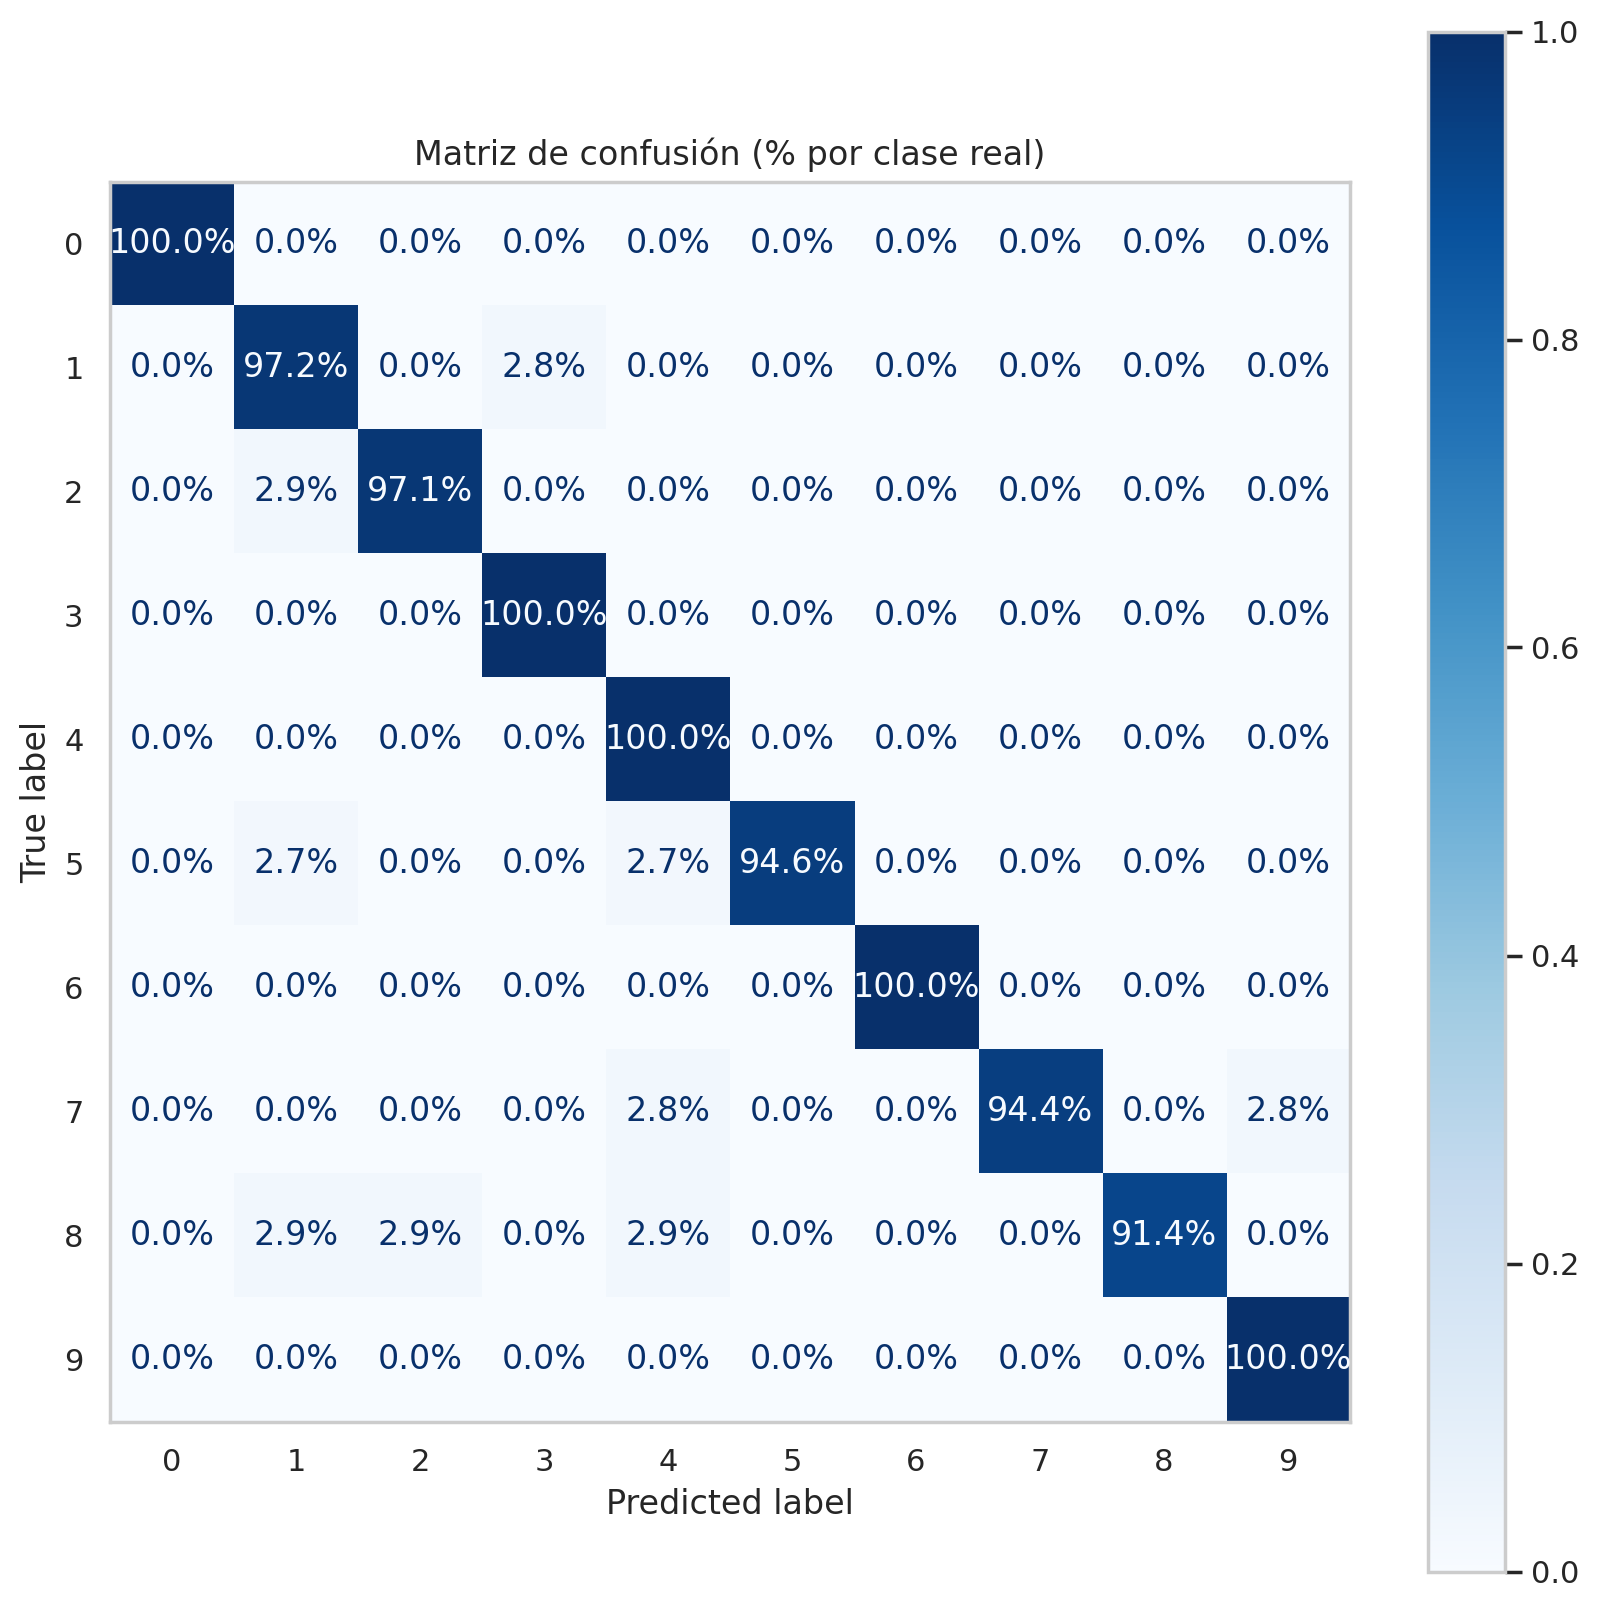

In [34]:
from sklearn.datasets import load_digits
digits = pd.concat([load_digits(as_frame=True).data, load_digits(as_frame=True).target], axis=1)
digits['target'] = digits['target'].astype('category')

strain_raw, stest_raw = split_sample(digits, 'target', 0.2, 123, True)
strain_d, prep_d = preprocesar_datos(strain_raw, 'target')
stest_d,  _      = preprocesar_datos(stest_raw,  'target', prep_d)
xtr_d, ytr_d = strain_d.drop('target', axis=1), strain_d['target']
xte_d, yte_d = stest_d.drop('target', axis=1),  stest_d['target']

modelo_d = LogisticRegression(max_iter=5000).fit(xtr_d, ytr_d)
print('coef_ (K, p):', modelo_d.coef_.shape, '| accuracy test:', round(modelo_d.score(xte_d, yte_d), 3))
matriz_confusion(modelo_d, xte_d, yte_d);

Con 10 clases, `coef_` tiene forma $(10, 64)$: un vector por dígito sobre los 64 píxeles. La matriz de confusión muestra una **diagonal fuerte** y revela las confusiones típicas (dígitos de forma parecida). Pese a ser **lineal**, la regresión logística multinomial alcanza una exactitud notable, sirviendo de **referencia** (*baseline*) frente a modelos más complejos.



## <font color="steelblue">11.1. Reducción con componentes principales</font>

Los 64 píxeles están muy **correlacionados** (píxeles vecinos se parecen), así que PCA debería comprimir mucho. Tomamos las componentes para **≥ 70 %** de la varianza, visualizamos CP1–CP2 por dígito y entrenamos el modelo sobre las componentes.

Componentes para ≥70% de varianza: 15 de 64  (varianza acumulada = 71.3%)


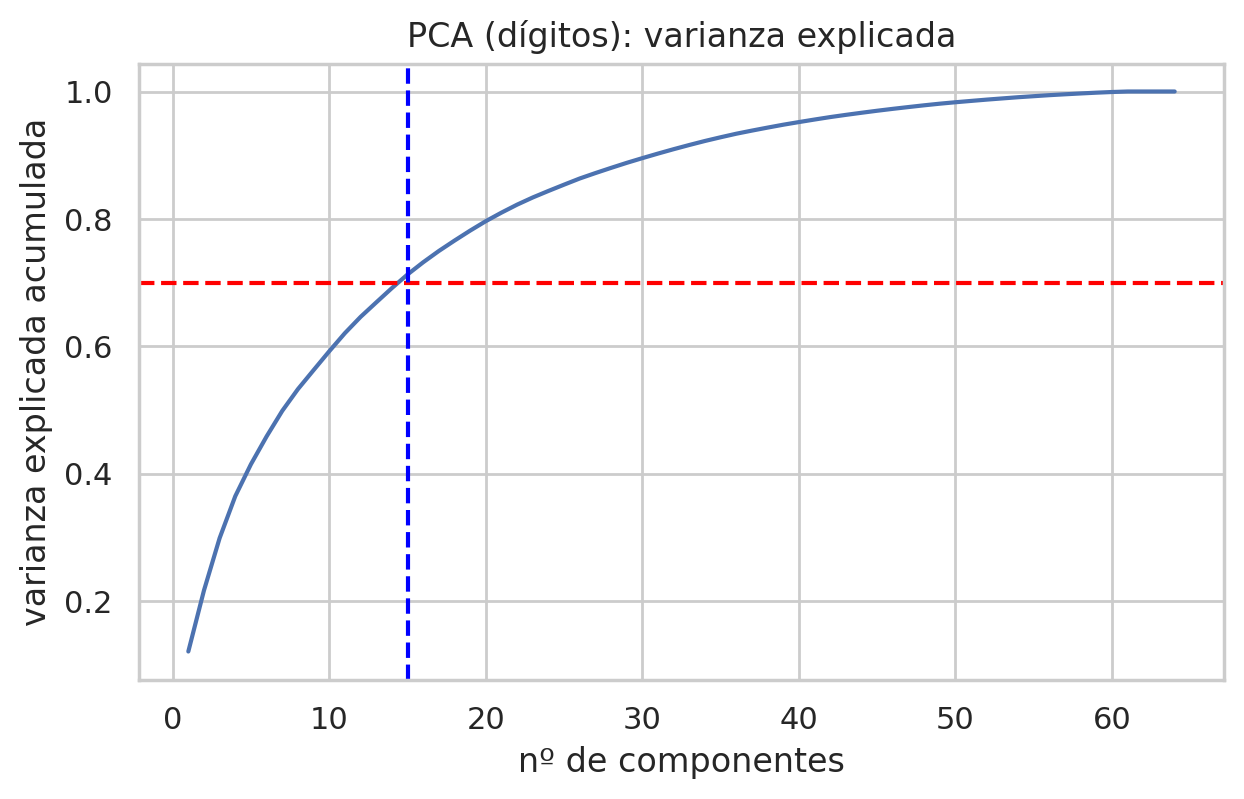

In [35]:
pca_d_full = PCA().fit(xtr_d)
var_acum_d = np.cumsum(pca_d_full.explained_variance_ratio_)
k70_d = int(np.argmax(var_acum_d >= 0.70) + 1)
print(f'Componentes para ≥70% de varianza: {k70_d} de 64  (varianza acumulada = {var_acum_d[k70_d-1]:.1%})')

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_acum_d)+1), var_acum_d, '-')
plt.axhline(0.70, color='red', ls='--')
plt.axvline(k70_d, color='blue', ls='--')
plt.xlabel('nº de componentes')
plt.ylabel('varianza explicada acumulada')
plt.title('PCA (dígitos): varianza explicada')
plt.show()

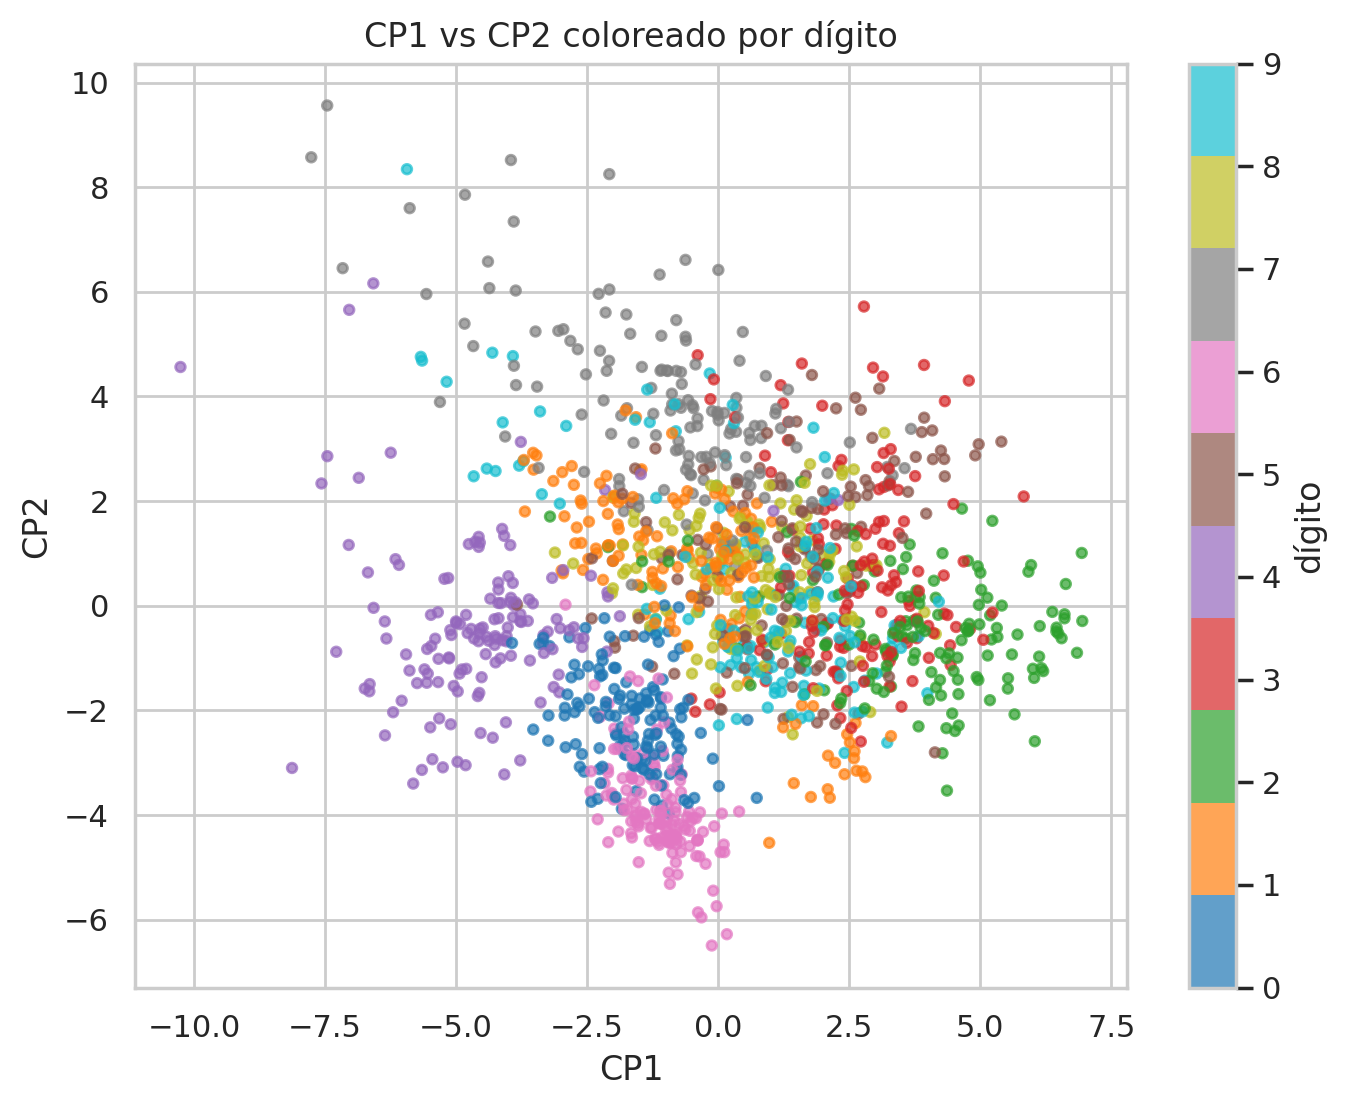

In [36]:
pca_d = PCA(n_components=k70_d).fit(xtr_d)
Xtr_dp = pca_d.transform(xtr_d)
Xte_dp = pca_d.transform(xte_d)

plt.figure(figsize=(8, 6))
sc = plt.scatter(Xtr_dp[:, 0], Xtr_dp[:, 1], c=ytr_d.astype(int), cmap='tab10', s=12, alpha=.7)
plt.colorbar(sc, label='dígito', ticks=range(10))
plt.xlabel('CP1')
plt.ylabel('CP2')
plt.title('CP1 vs CP2 coloreado por dígito')
plt.show()

=== Dígitos sobre 15 componentes principales ===
Accuracy test — original (64 vars): 0.975 |  PCA (15 comp): 0.953


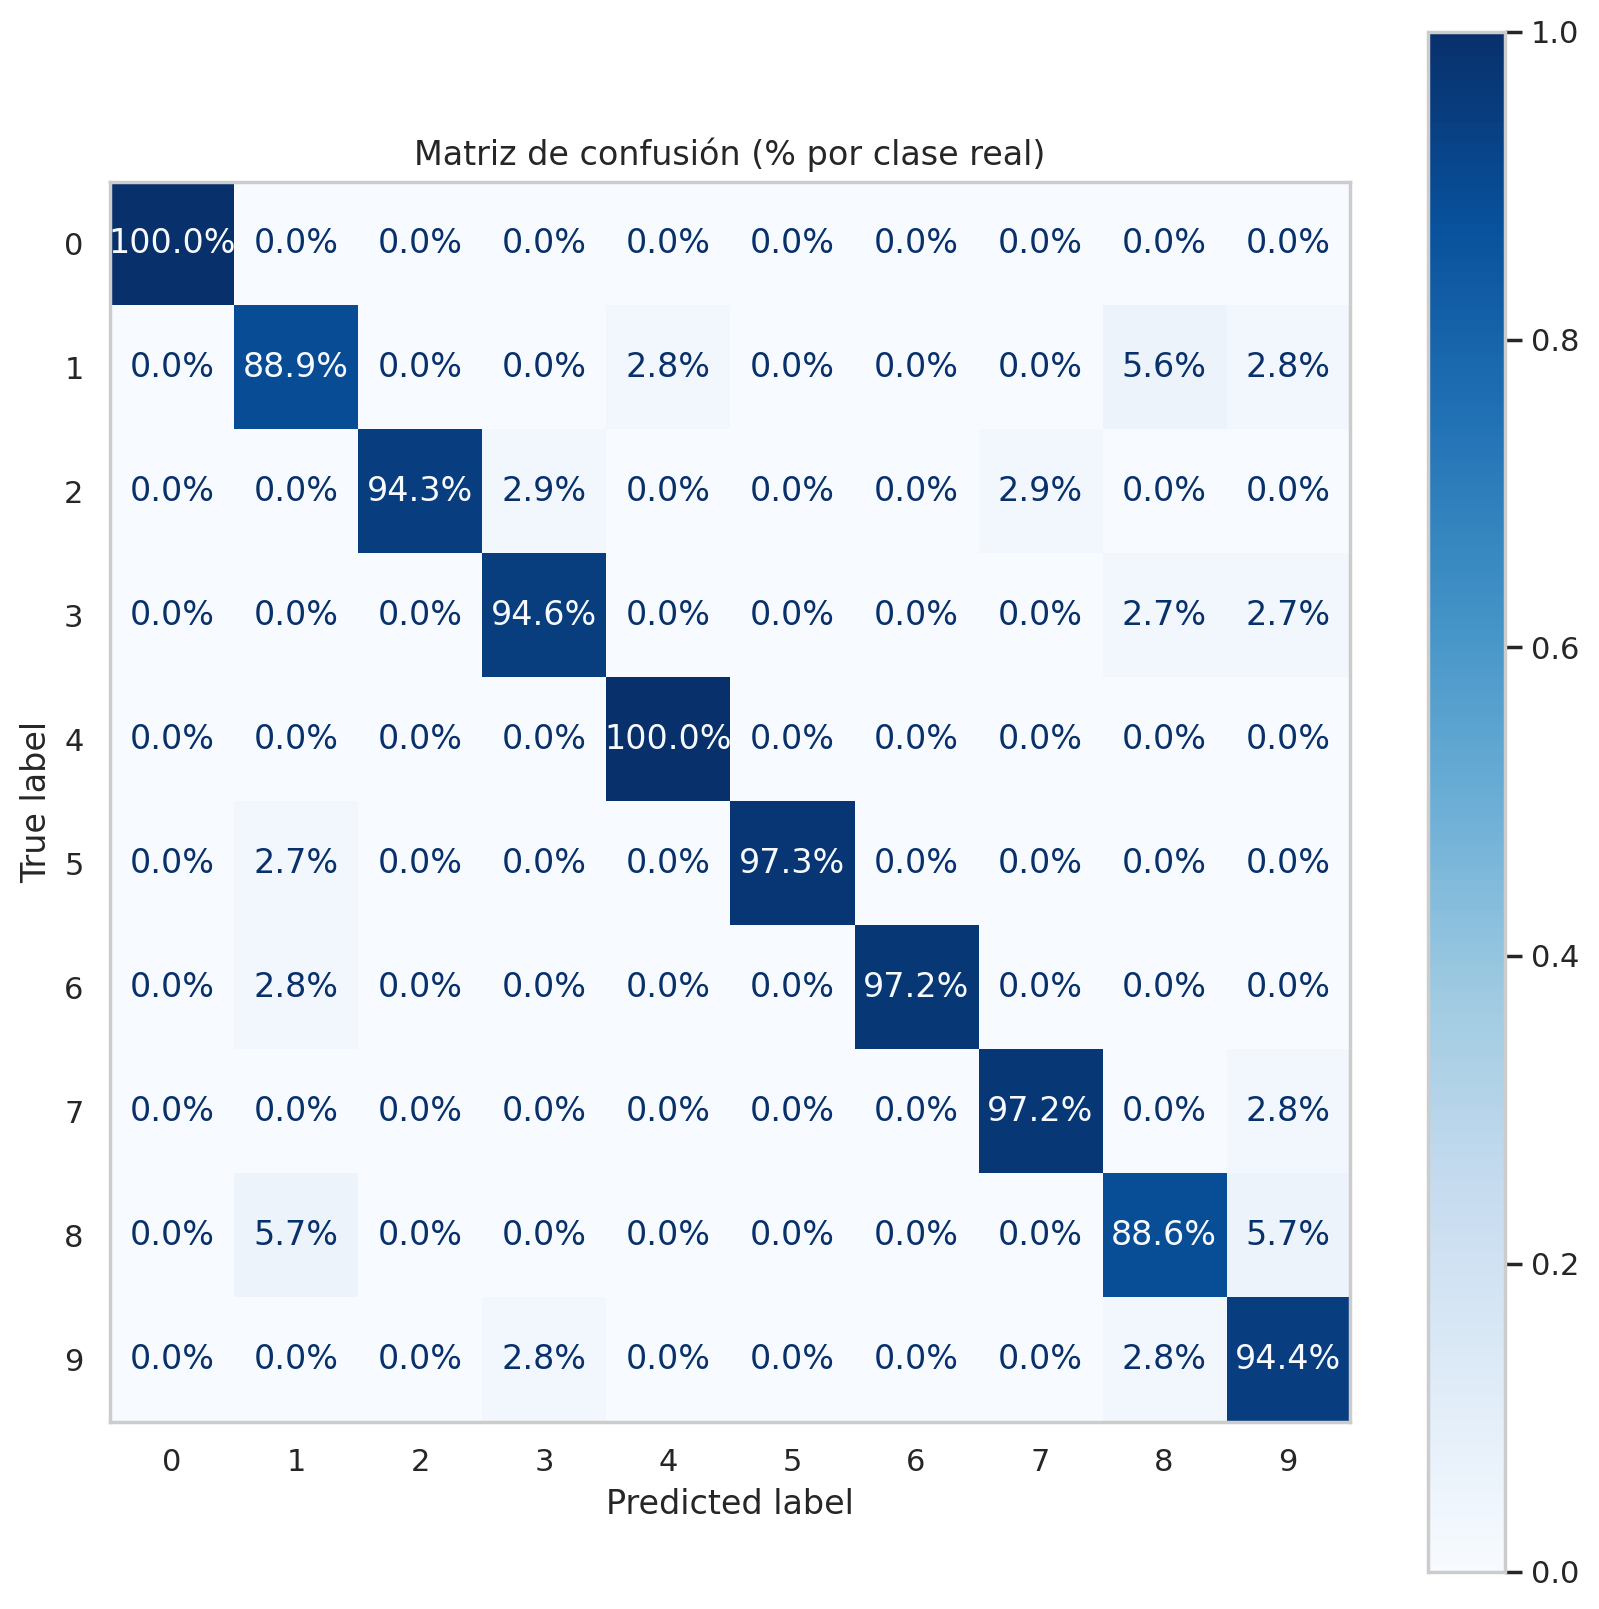

In [38]:
modelo_dp = LogisticRegression(max_iter=5000).fit(Xtr_dp, ytr_d)
print(f'=== Dígitos sobre {k70_d} componentes principales ===')
print('Accuracy test — original (64 vars):', round(modelo_d.score(xte_d, yte_d), 3),
      f'|  PCA ({k70_d} comp):', round(modelo_dp.score(Xte_dp, yte_d), 3))
matriz_confusion(modelo_dp, Xte_dp, yte_d);

Bastan **~15 componentes** (de 64) para conservar el 70 % de la varianza, lo que **reduce la dimensión a menos de una cuarta parte**. En el plano CP1–CP2 (solo 2 de esas componentes) ya se intuyen **agrupaciones por dígito**, aunque con bastante solape: distinguir 10 clases en 2 dimensiones es exigente. El modelo entrenado sobre las 15 componentes mantiene una exactitud **muy próxima** a la del modelo con los 64 píxeles (apenas un par de puntos porcentuales menos), confirmando que la información discriminante está **concentrada** en pocas direcciones. Es un buen ejemplo de PCA como **preprocesado** que acelera y simplifica el modelo con un coste mínimo de rendimiento.


In [39]:
# Validación cruzada (f1_weighted) del modelo ponderado
val_bal = validar_modelo(modelo_dp, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.979 +/- 0.046
